# Standard Maxx Analysis Template


## Notes
**Overview:** This experiment is designt to test whether flies in which activation of R4d neurons exhibit positive or negative valence.  
**Rationale:** We found that activation of R2 alone neurons was aversive and that R2/R4 activation may be attractive.  Both R2 and R2/R4 activation increases lifespan.    
**Date of Experiment:** 12/13/2024   
**Genotypes:** R4d-Gal4xWCS; R4d-Gal4xChrimson   
**Sex:** Males   
**Light Paradigm:** 10min aclimation period with no lights; 60 min 5sec on/5 sec off; 10 min cool down with no lights. 40Hz/32% DC. 18V.
**Design:** Alternating Control,Chrimson starting with T_0 (top left lane) and alternating throughout.  Details in the _Notes.txt_ file.   
**Misc:** This run was messed up because the left side of the Maxx was not correctly running the program.  The start time was off and it ended early.  It's not clear when the lights were actually on.  A separate treatment was made for these.  I would not completely trust the right side either, but the data are here for comparison.

## Configuration
Configuration was standard. No new or untested code.

In [1]:
#%autoreload 1
import warnings
from Arena import *
import Tracker
import TwoChoiceTracker
from ExperimentalDesign import *
from Parameters import *

# Suppress all warnings
warnings.filterwarnings('ignore')

## Parameters
Just a standard arena max, accepting the default values and a Two-Choice Tracker.

In [2]:
p=Parameters()
p.set_arena_max_values(TrackingType.TWOCHOICETRACKER)
p.print()

tracking_type: TrackingType.TWOCHOICETRACKER
fps: 0
mm_per_pixel: 0.145
speed_window_seconds: 1
micromove_speed_mm_sec: [0.2, 2]
walking_speed_mm_sec: 2
sleep_threshold_min: 5
interaction_distances: [8]


## Read in the data

Next we will read in the data to an Arena object. The format is`Arena(ExperimentName, parameters, data_path="./")`. This will automatically calculate all relevant metrics for the tracking type in question.  

The name of the experiment and predefined parameters object are required, but _data_path_ is optional (if no data directory is specified, it defaults to the current working directory).

The following files must be present in the defined data directory :
* The DTrack experiment file, which is an excel sheet with the name '_ExperimentName.xlsx_'.
* The DTrack data files themselves, which are named '_ExperimentName_Data_1.csv_', '_ExperimentName_Data_2.csv_', etc.
* An experiment file (most of the time, definitely for a TwoChoiceTracker), which is named '_ExperimentName_Design.txt_'.

In [3]:
data_path  = './Data/'
arena = Arena.Arena(p,data_path=data_path)
arena.print_short_data_quality_report()

## Summary
Get the summary results for all trackers, including treatments, etc.   
This will copy the results to the clipboard and save the data in a file called '_ExperimentName_Summary.csv_'.   
The semicolon at the end of the command will suppress the output to this notebook.  Remove it if you want to see the results dataframe.

In [4]:
arena.summarize(copy_to_clipboard=True,write_to_csvfile=True);

Or you can also create a faceted summary if you want to separate the different phases of the experiment.   
The file name will be '_ExperimentName_Summary_Facet.csv_'.

In [5]:
arena.summarize_facet(cutoffs=(10,70),copy_to_clipboard=True,write_to_csvfile=True);

## Plotting
There are lots of cool plotting funtions.  Some are shown below.

**Facet plots:** First of PI, then Percentage, then Total Distance (in mm/min).   
Cutoffs separate the acclimaton phase from the experiment phase from the cool down phase.

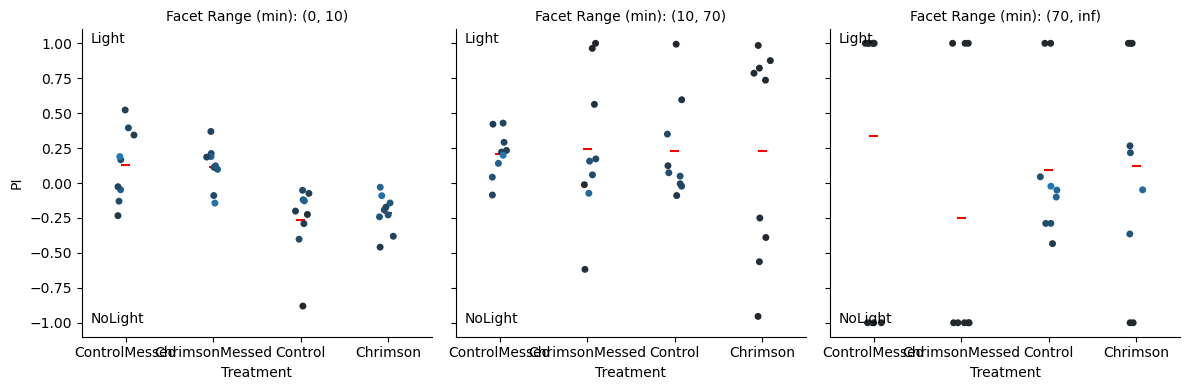

In [54]:
arena.plot_pi_facet(cutoffs=(10,70))

In [55]:
arena.run_pairwise_comparisons_facet(metric="FinalPI",cutoffs=(10,70))

Column = FinalPI, Facet Range = (0.00,10.00)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
      Chrimson ChrimsonMessed   0.3328 0.0098  0.0662  0.5995   True
      Chrimson        Control  -0.0482 0.9609 -0.3148  0.2185  False
      Chrimson  ControlMessed   0.3464 0.0069  0.0797  0.6131   True
ChrimsonMessed        Control   -0.381 0.0027 -0.6477 -0.1144   True
ChrimsonMessed  ControlMessed   0.0136  0.999 -0.2531  0.2802  False
       Control  ControlMessed   0.3946 0.0018  0.1279  0.6613   True
--------------------------------------------------------------------


Column = FinalPI, Facet Range = (10.00,70.00)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------
      Chrimso

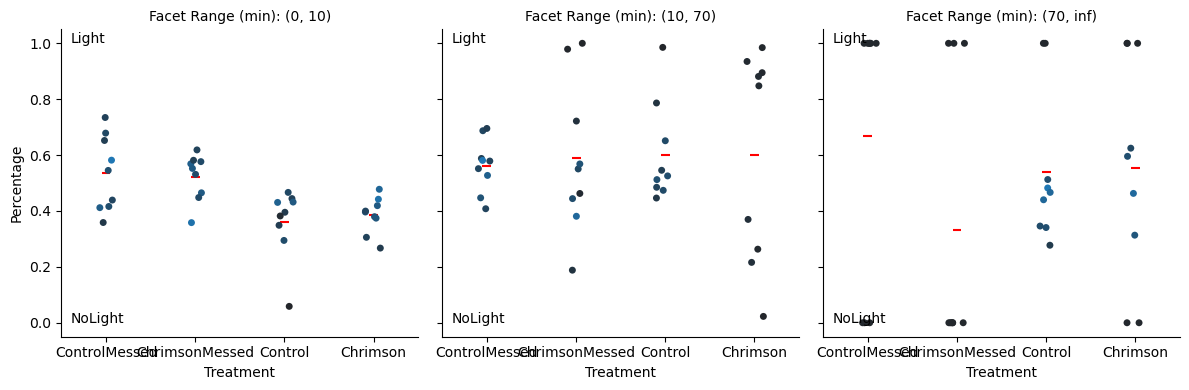

In [56]:
arena.plot_percentage_facet(cutoffs=(10,70))

In [57]:
arena.run_pairwise_comparisons_facet(metric="FinalPercentage",cutoffs=(10,70))

Column = FinalPercentage, Facet Range = (0.00,10.00)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
      Chrimson ChrimsonMessed   0.1376 0.0453  0.0022   0.273   True
      Chrimson        Control  -0.0232 0.9664 -0.1586  0.1122  False
      Chrimson  ControlMessed   0.1507 0.0245  0.0153  0.2862   True
ChrimsonMessed        Control  -0.1608 0.0149 -0.2962 -0.0254   True
ChrimsonMessed  ControlMessed   0.0131 0.9935 -0.1223  0.1485  False
       Control  ControlMessed   0.1739 0.0076  0.0385  0.3093   True
--------------------------------------------------------------------


Column = FinalPercentage, Facet Range = (10.00,70.00)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------

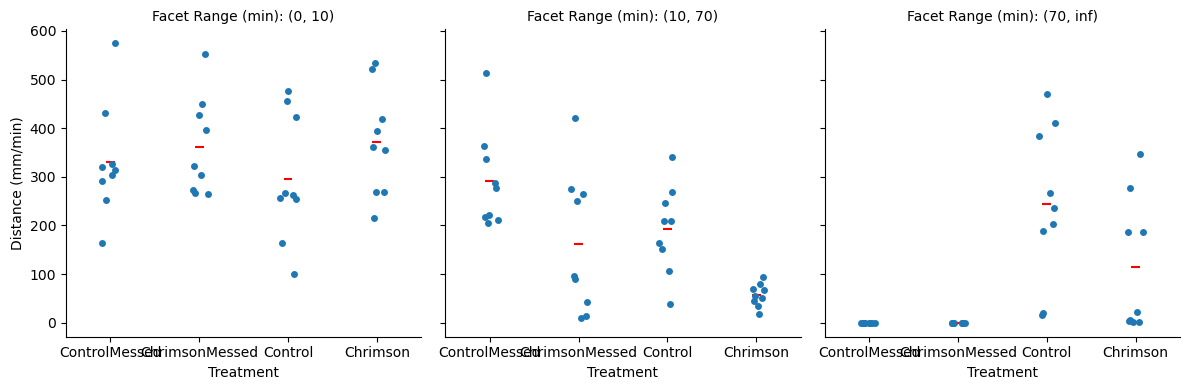

In [58]:
arena.plot_totaldistance_facet(cutoffs=(10,70))

In [59]:
arena.run_pairwise_comparisons_facet(metric="TotalDistance",cutoffs=(10,70))

Column = TotalDistance, Facet Range = (0.00,10.00)
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
    group1         group2      meandiff p-adj    lower      upper   reject
--------------------------------------------------------------------------
      Chrimson ChrimsonMessed  -95.0268  0.998 -1554.8644 1364.8109  False
      Chrimson        Control   -753.97  0.509 -2213.8077  705.8676  False
      Chrimson  ControlMessed -401.7953 0.8778 -1861.6329 1058.0424  False
ChrimsonMessed        Control -658.9433 0.6172 -2118.7809  800.8944  False
ChrimsonMessed  ControlMessed -306.7685 0.9405 -1766.6061 1153.0691  False
       Control  ControlMessed  352.1748 0.9135 -1107.6629 1812.0124  False
--------------------------------------------------------------------------


Column = TotalDistance, Facet Range = (10.00,70.00)
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
    group1         group2      meandiff  p-adj    lower      upper  

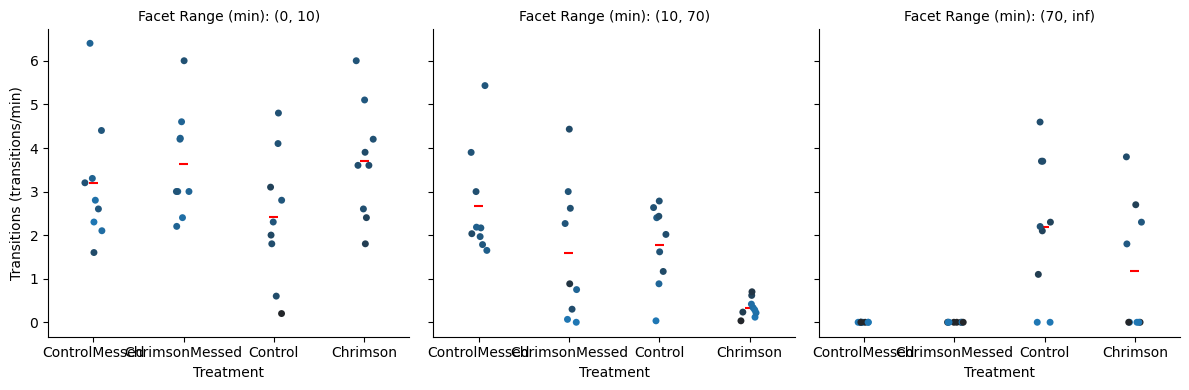

In [60]:
arena.plot_transitions_facet(cutoffs=(10,70))

In [61]:
arena.run_pairwise_comparisons_facet(metric="Transitions",cutoffs=(10,70))

Column = Transitions, Facet Range = (0.00,10.00)
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------
      Chrimson ChrimsonMessed  -0.6667 0.9996 -18.2605 16.9271  False
      Chrimson        Control -12.7778 0.2213 -30.3716   4.816  False
      Chrimson  ControlMessed     -5.0 0.8674 -22.5938 12.5938  False
ChrimsonMessed        Control -12.1111  0.263 -29.7049  5.4827  False
ChrimsonMessed  ControlMessed  -4.3333 0.9086 -21.9271 13.2605  False
       Control  ControlMessed   7.7778 0.6327   -9.816 25.3716  False
---------------------------------------------------------------------


Column = Transitions, Facet Range = (10.00,70.00)
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
    group1         group2     meandiff p-adj   lower    upper   reject
---------------------------------------------------------

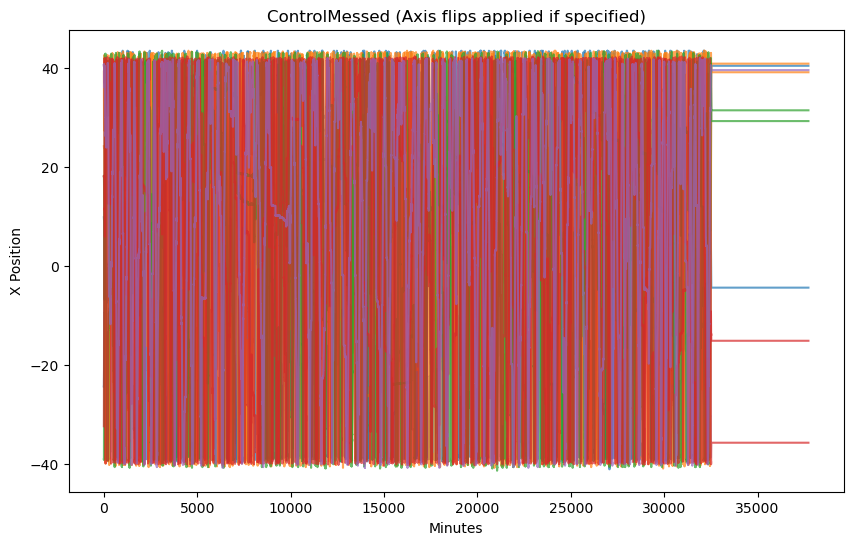

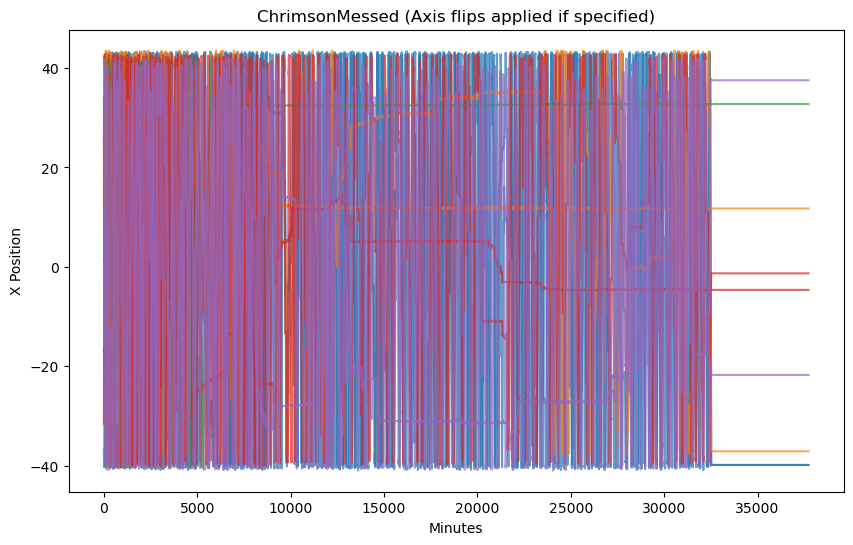

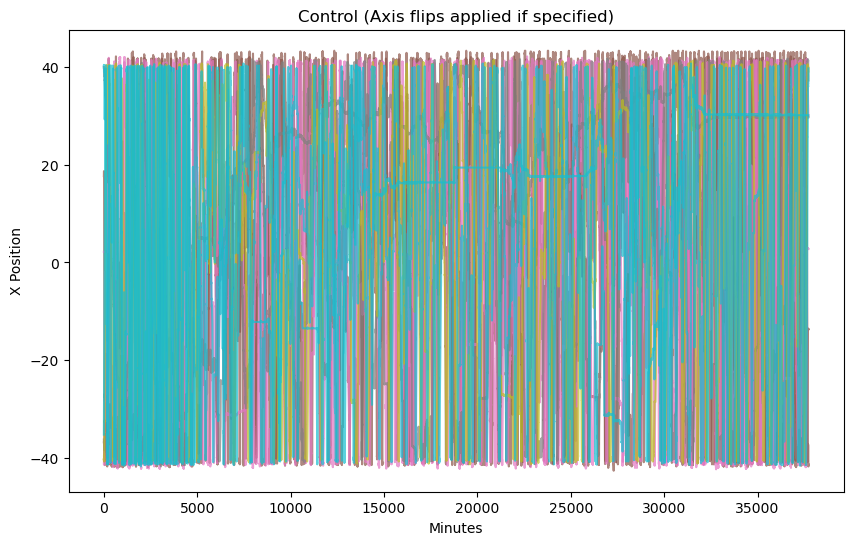

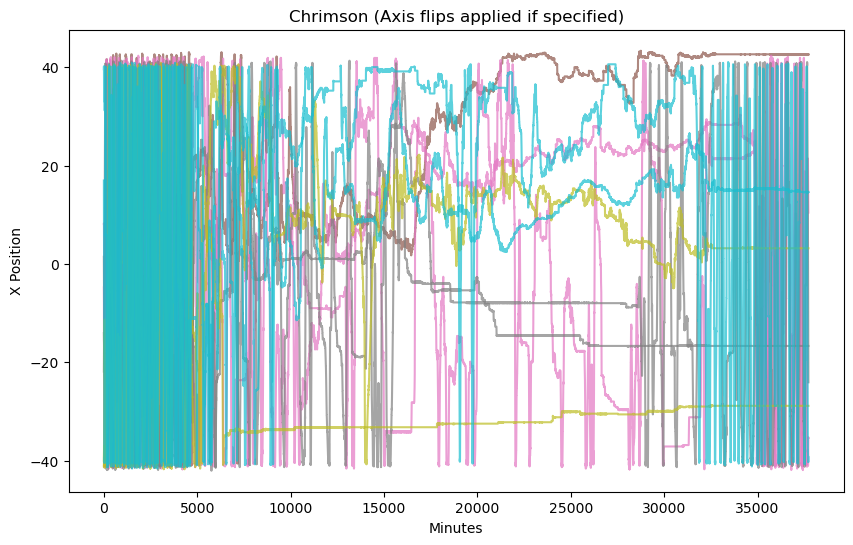

In [62]:
arena.plot_trackers_x(one_plot=True)

**Tracker plots:** These show, for each tracker individually, the progression of PI and Percentage showing cumulative values and time-dependent values

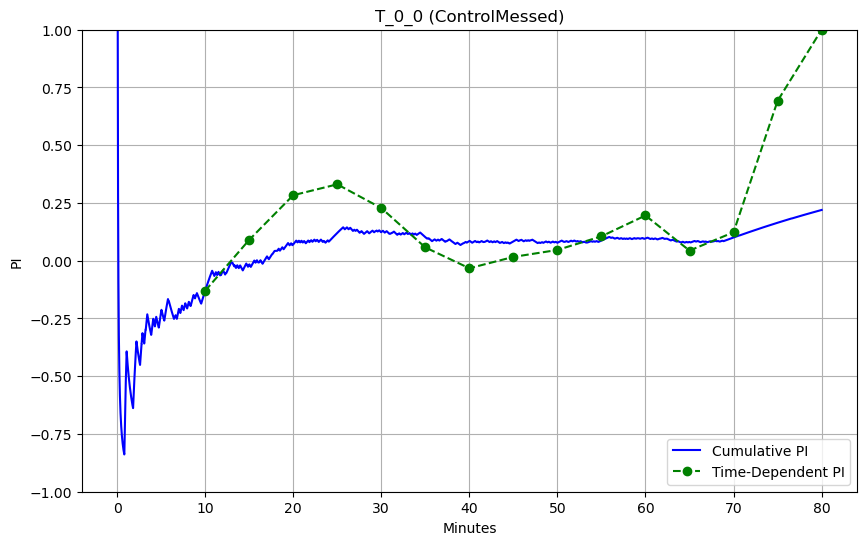

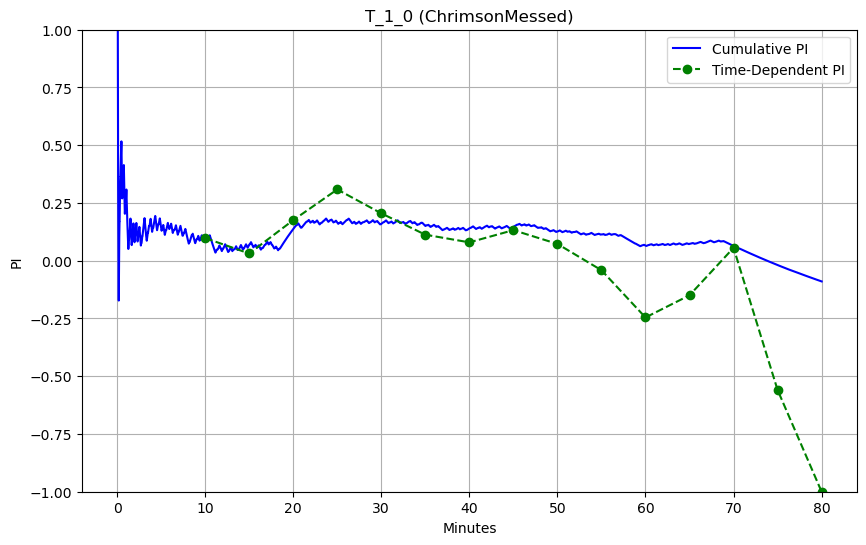

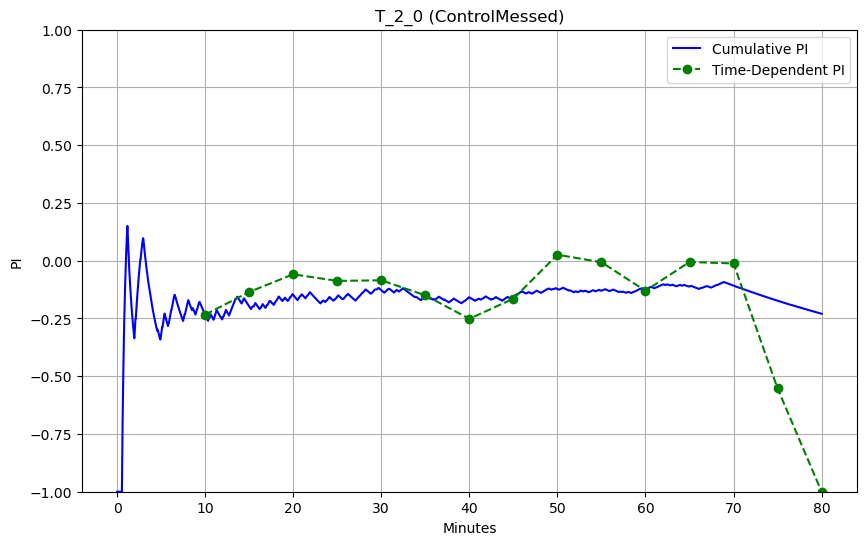

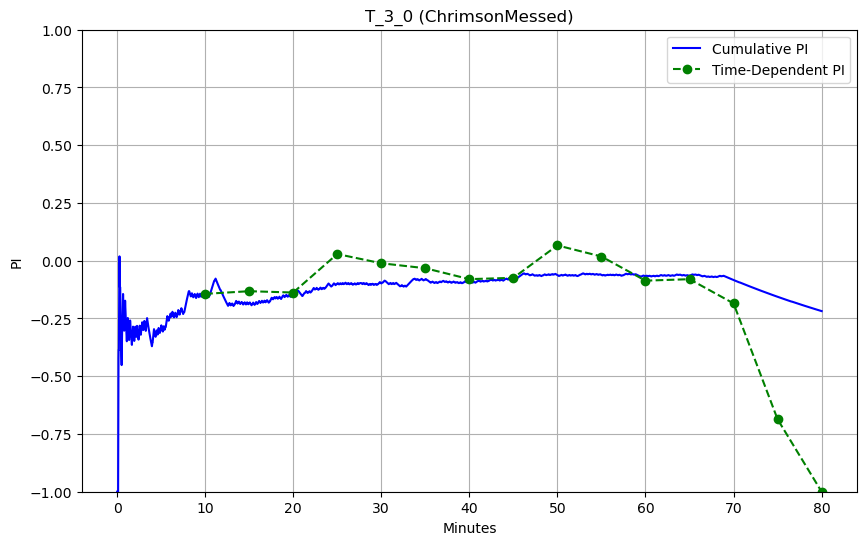

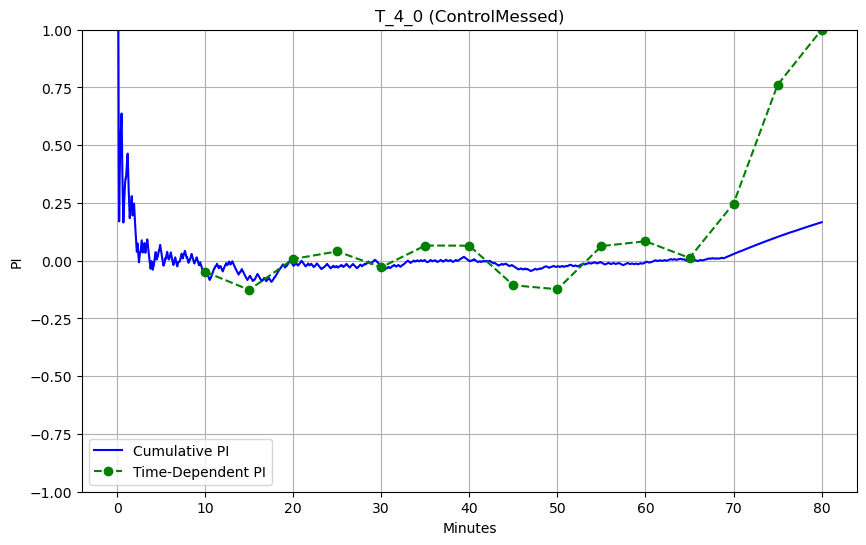

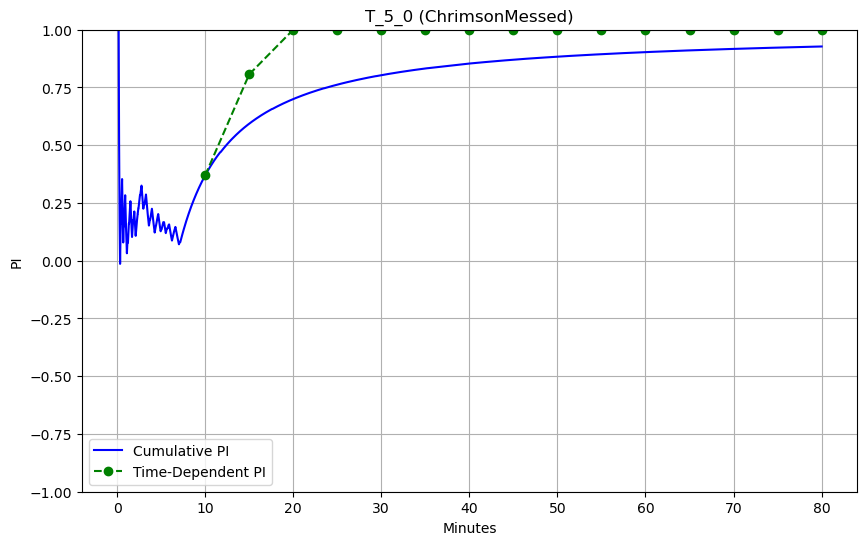

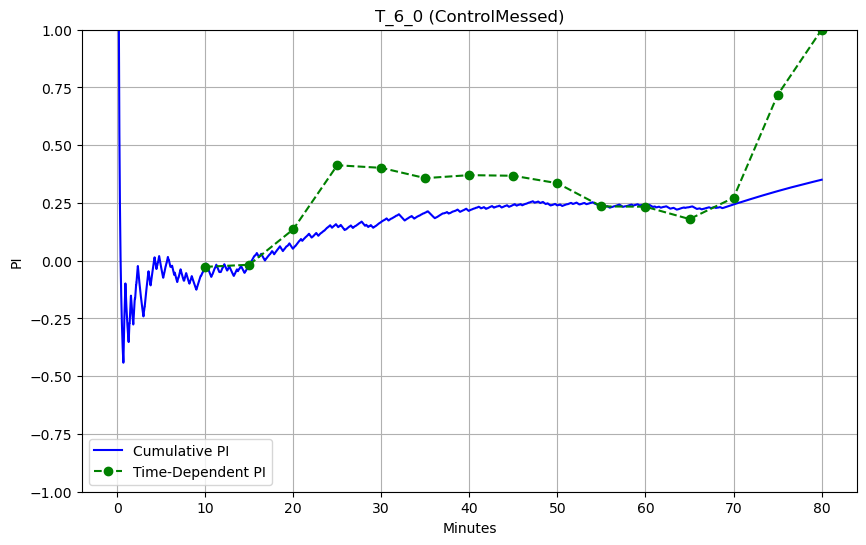

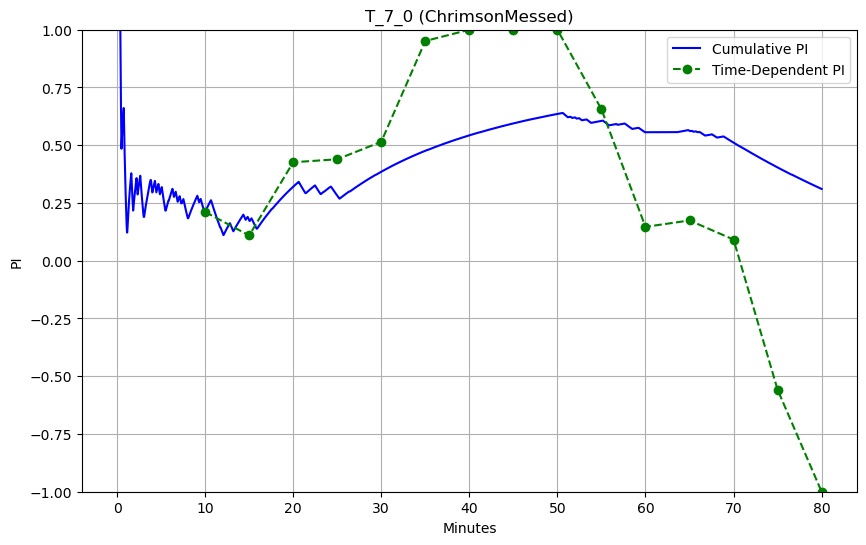

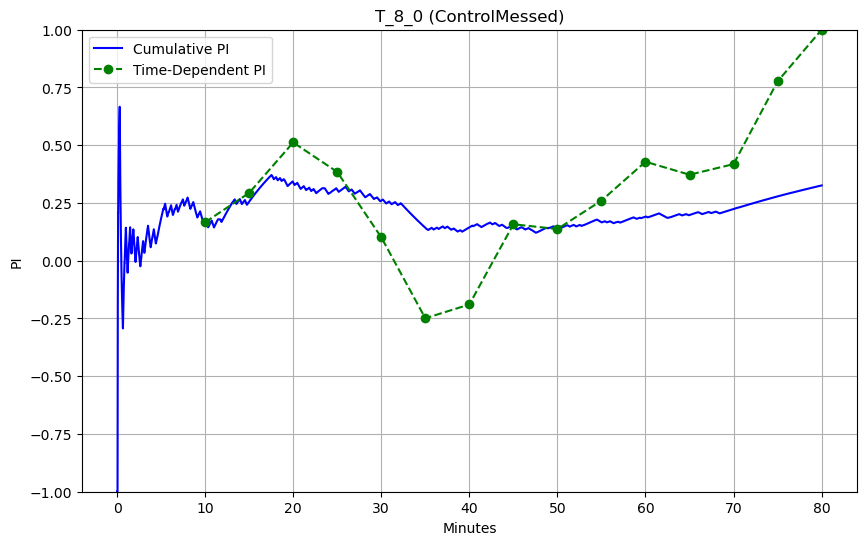

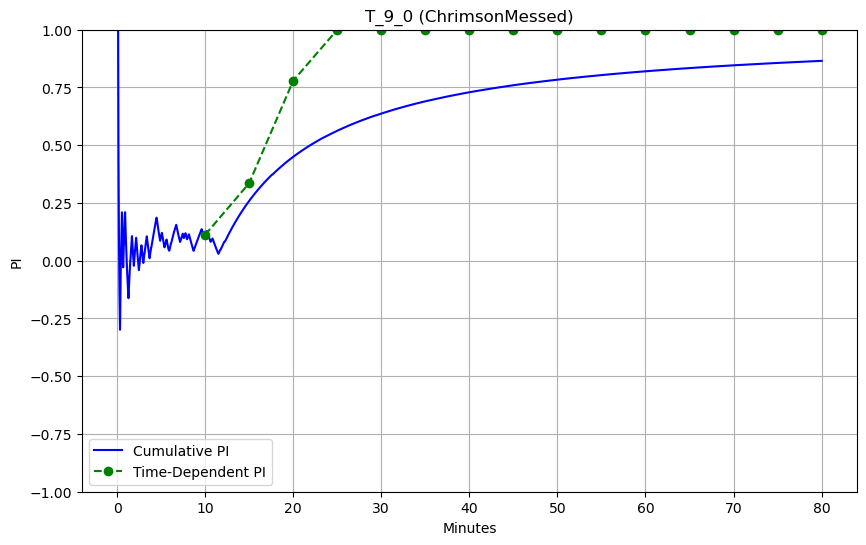

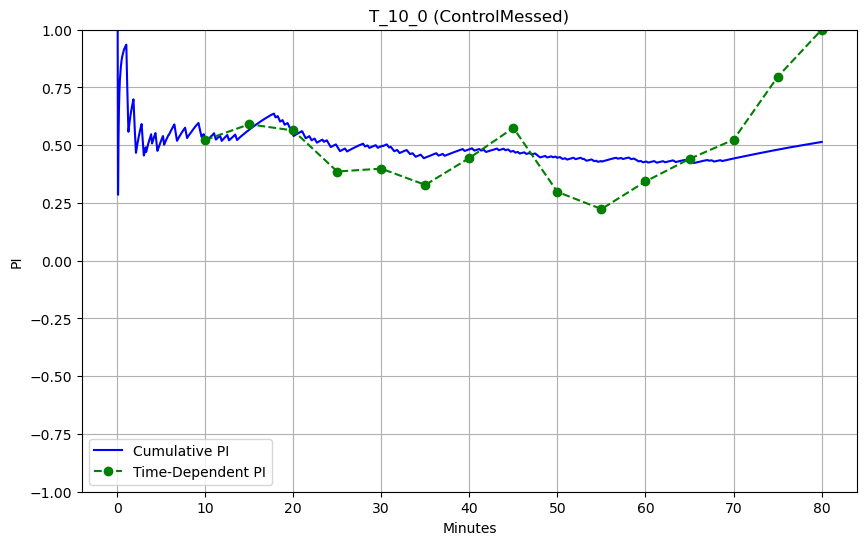

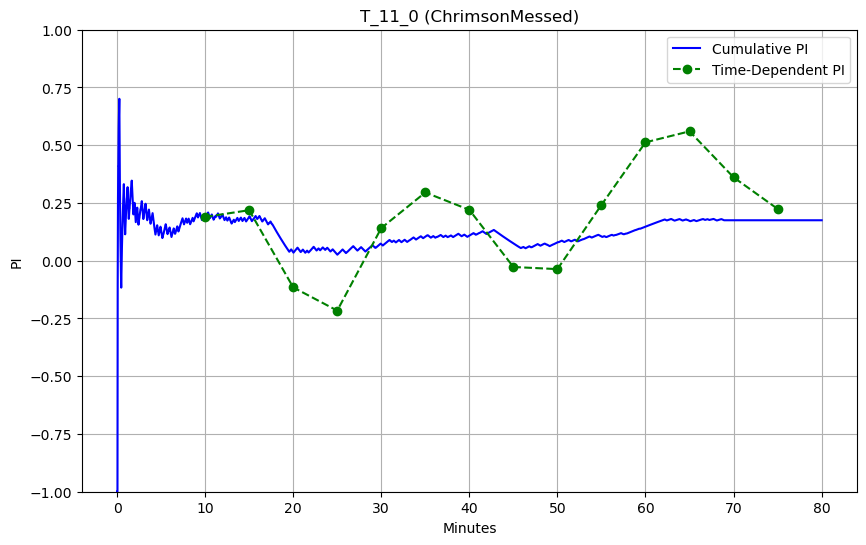

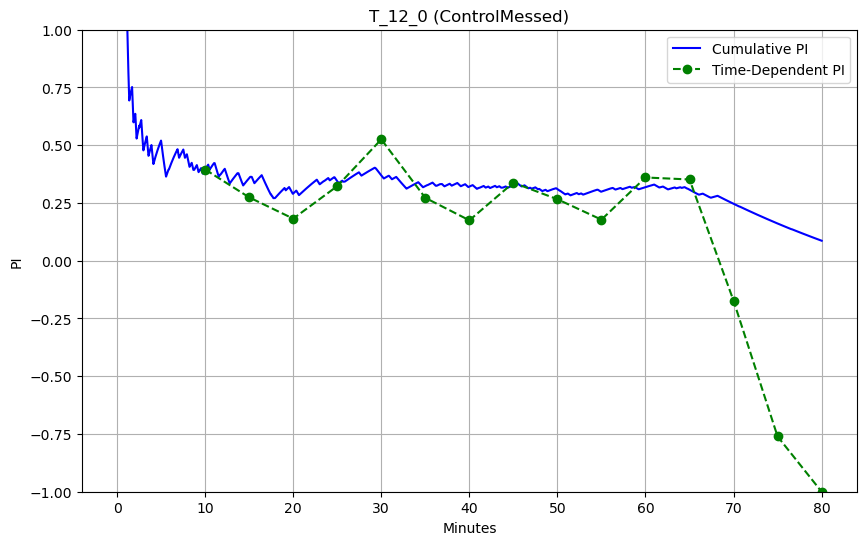

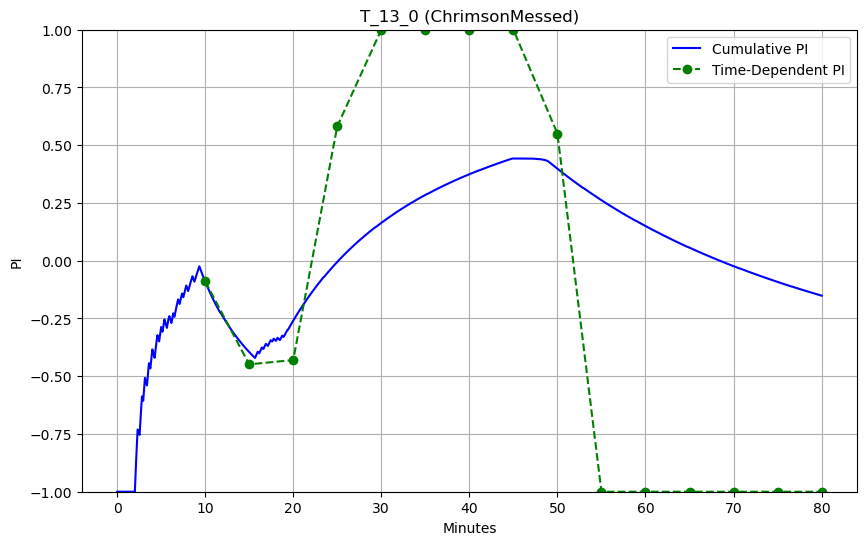

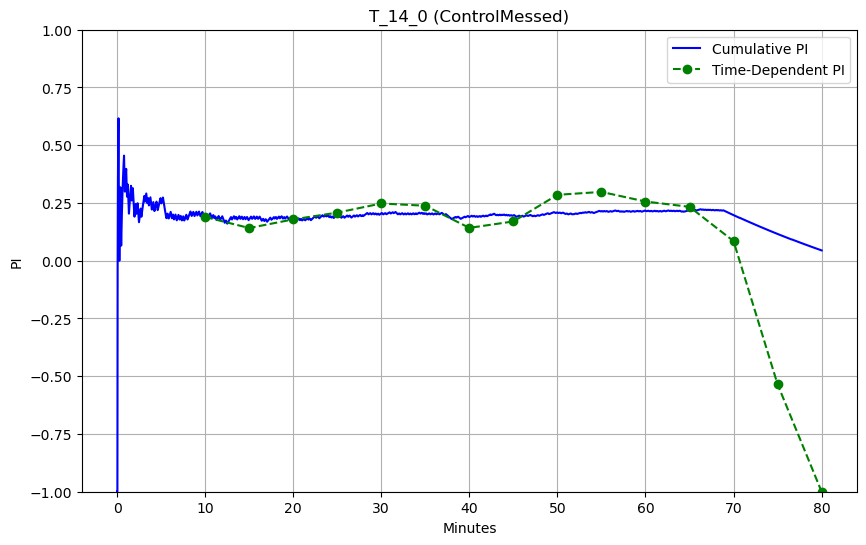

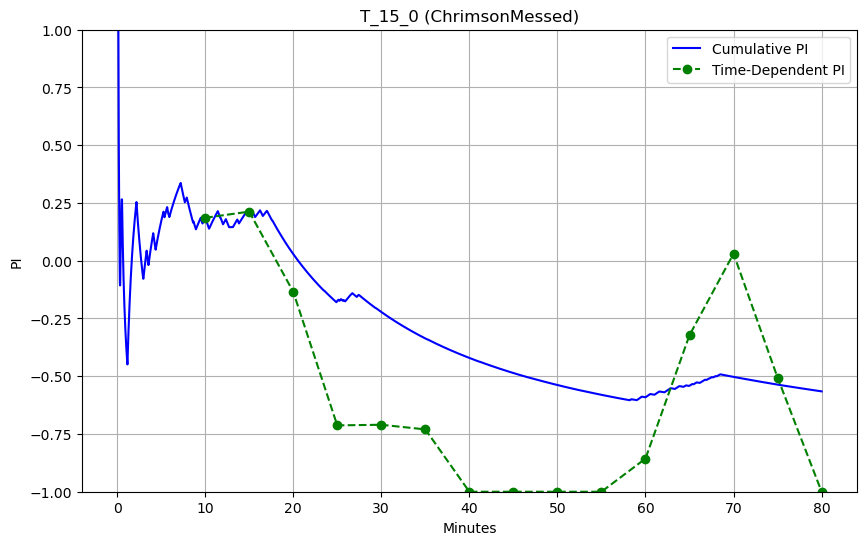

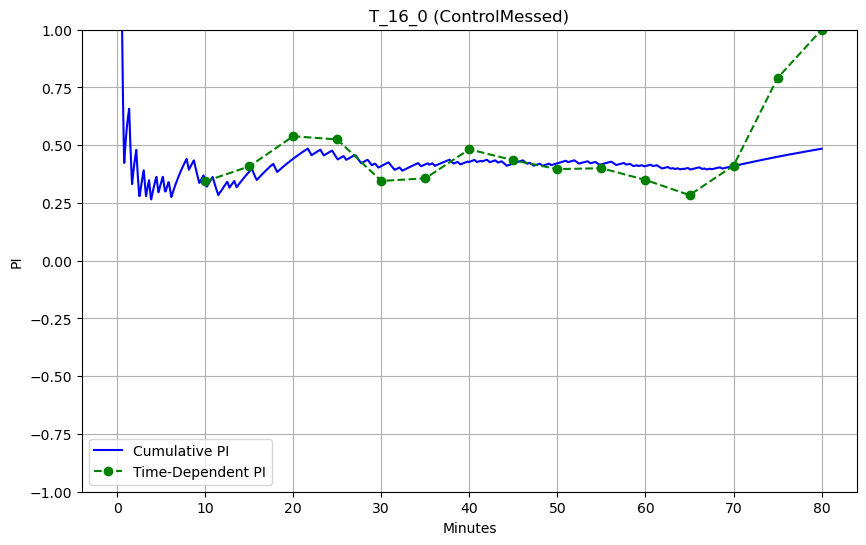

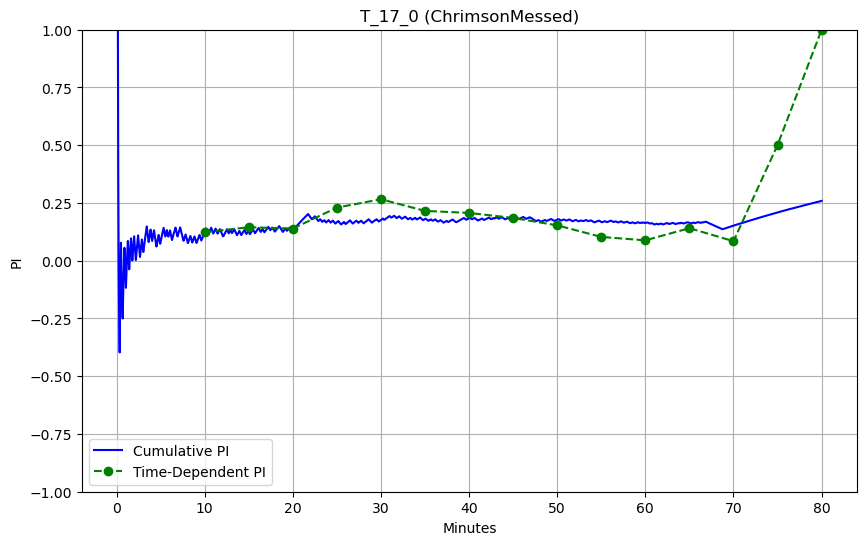

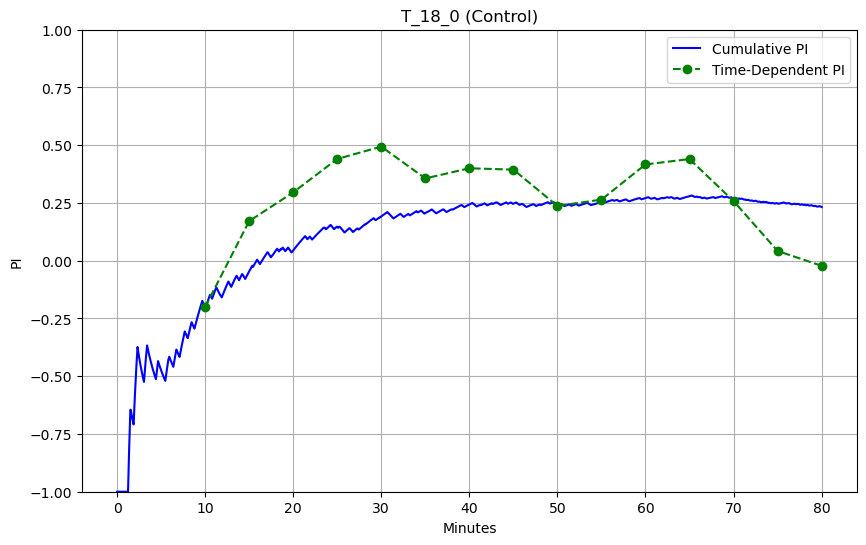

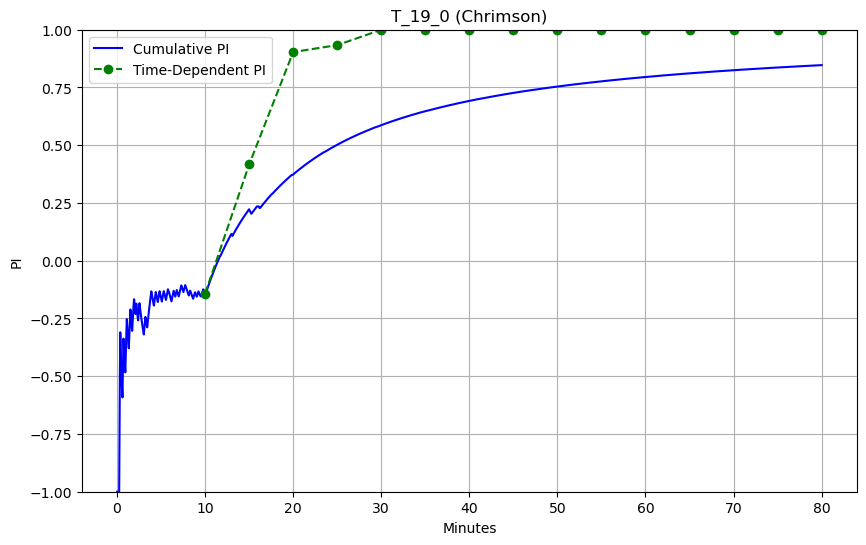

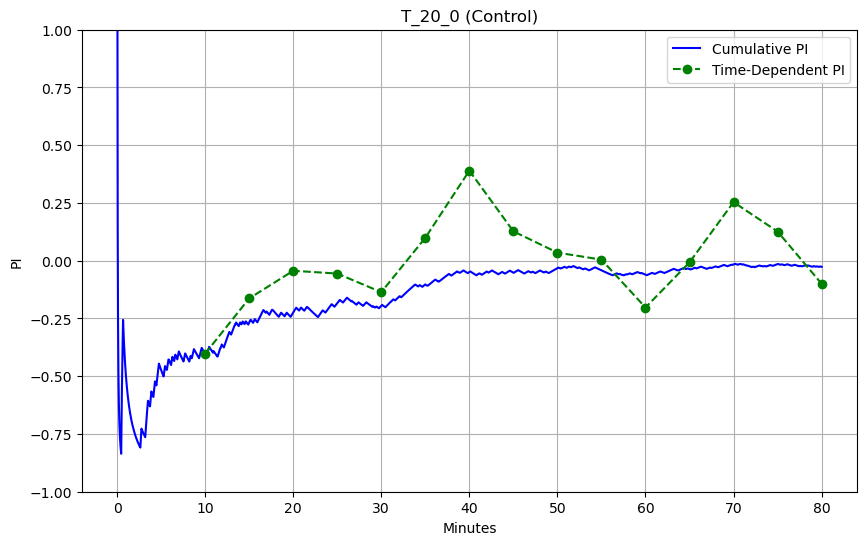

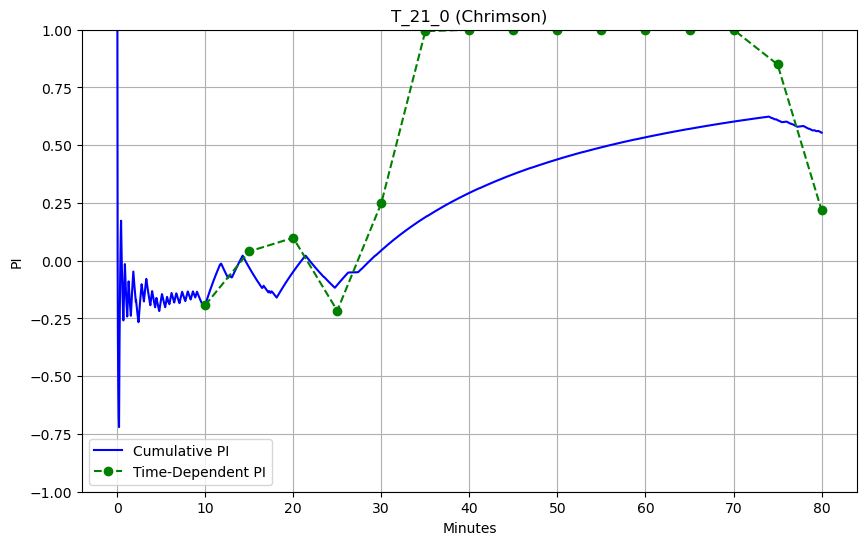

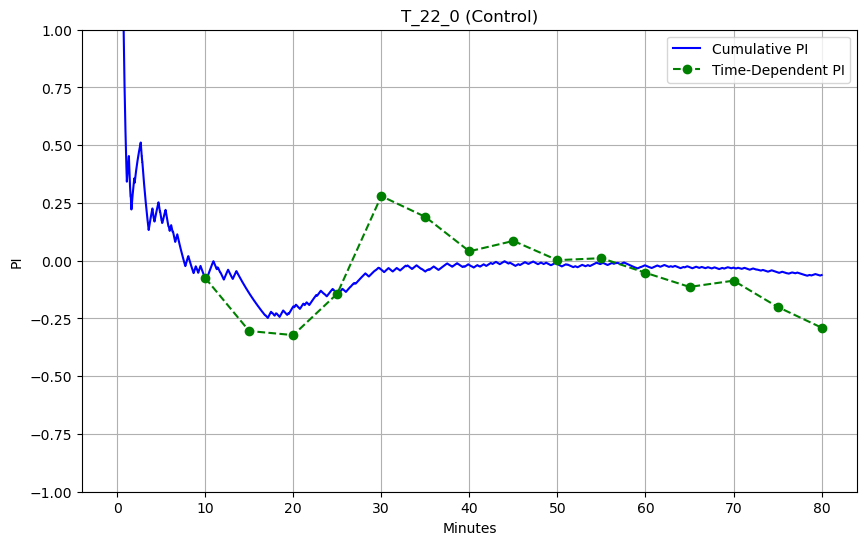

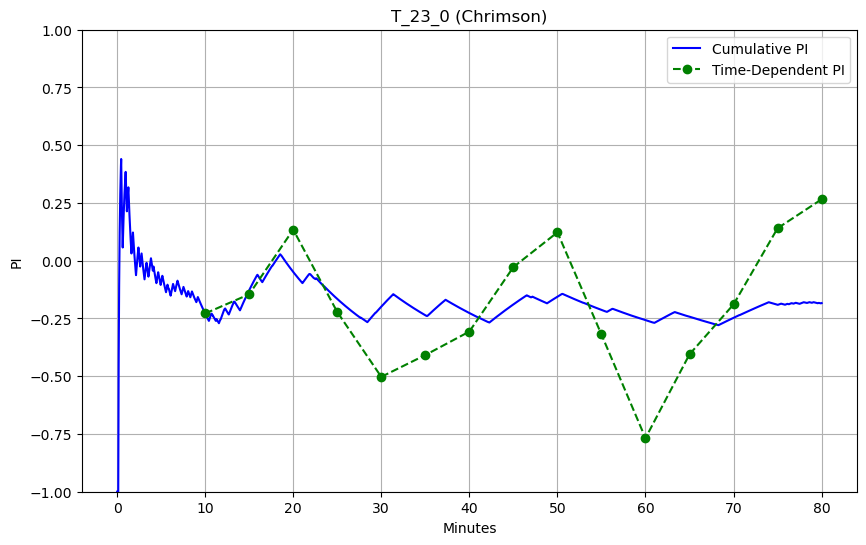

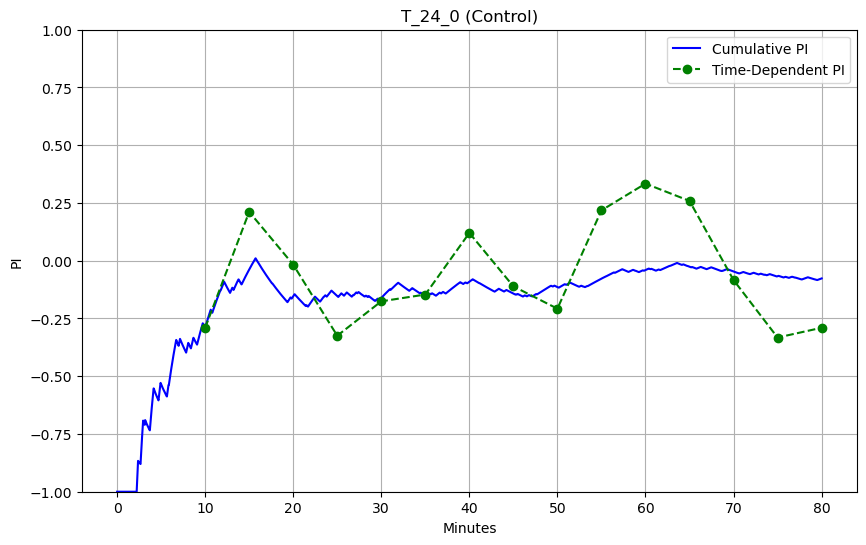

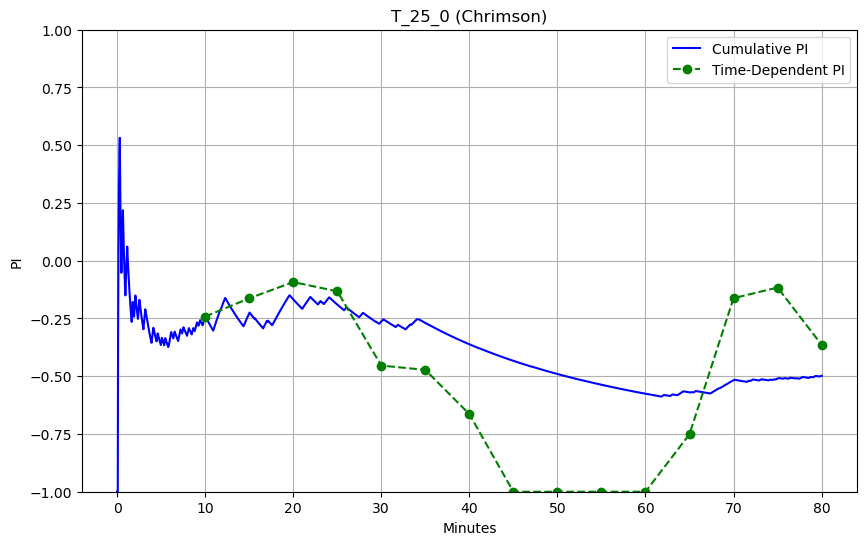

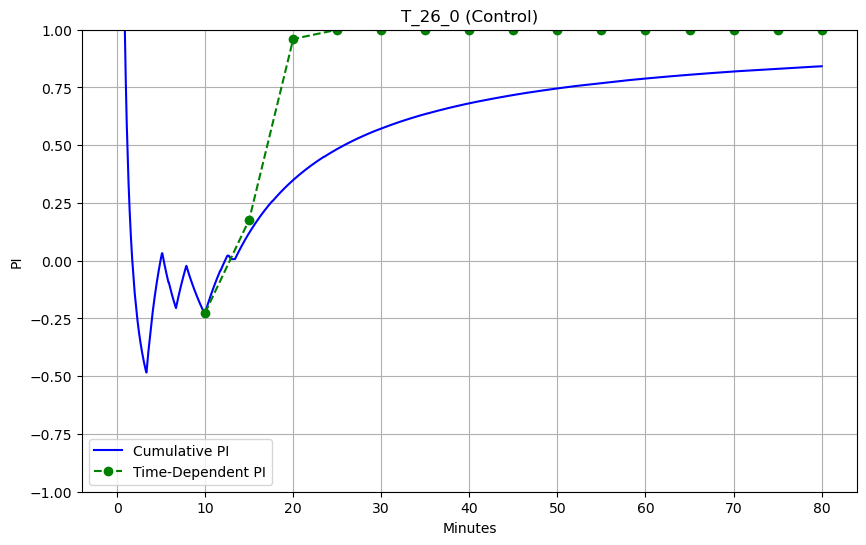

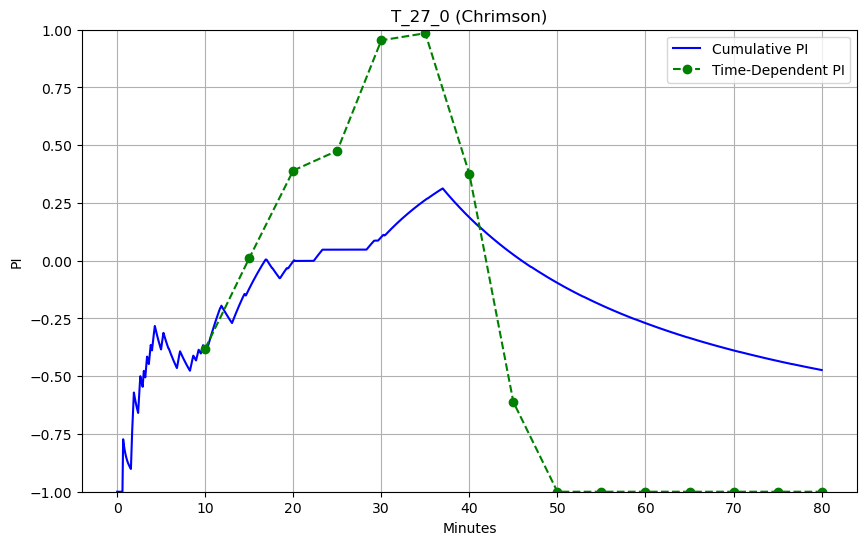

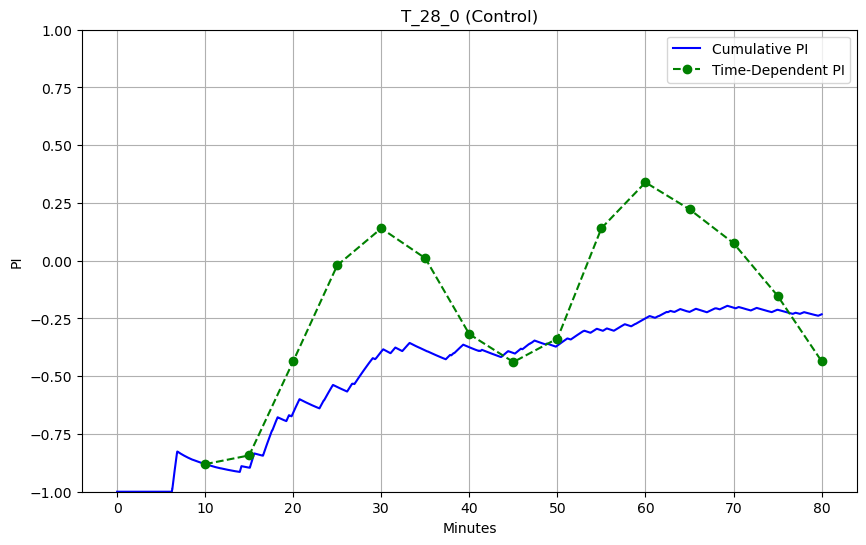

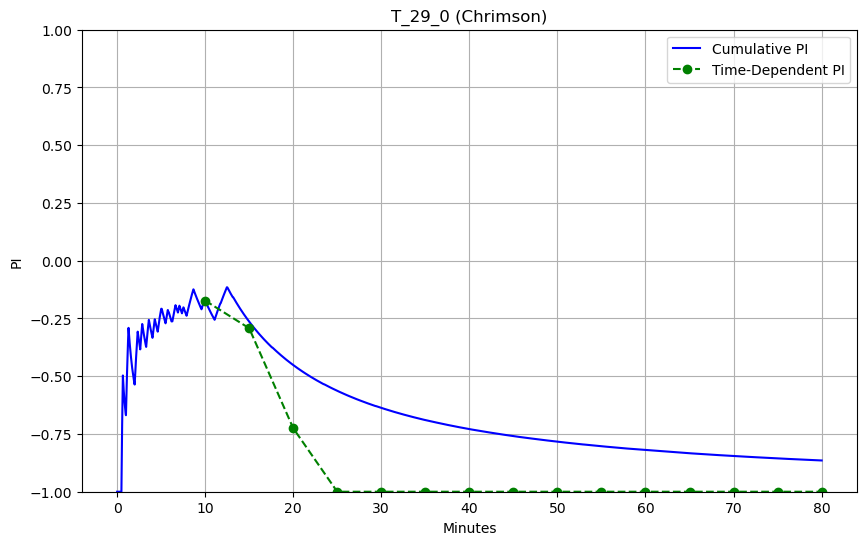

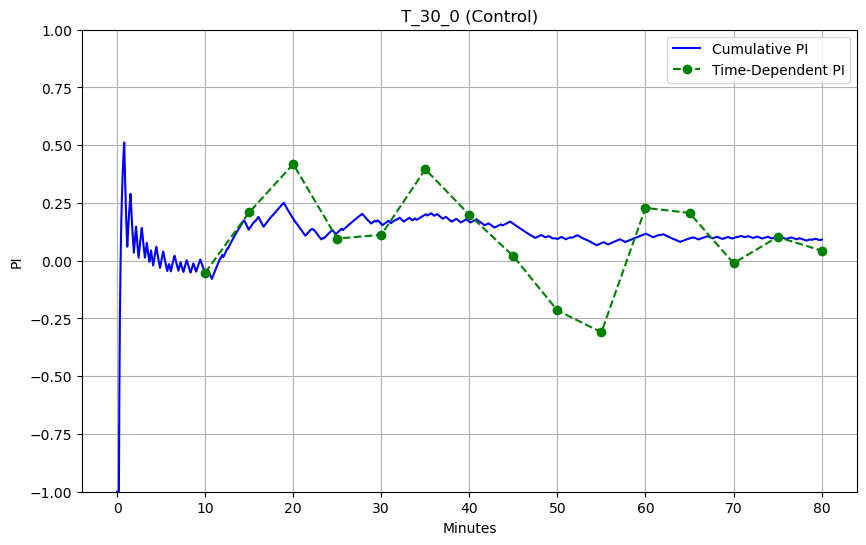

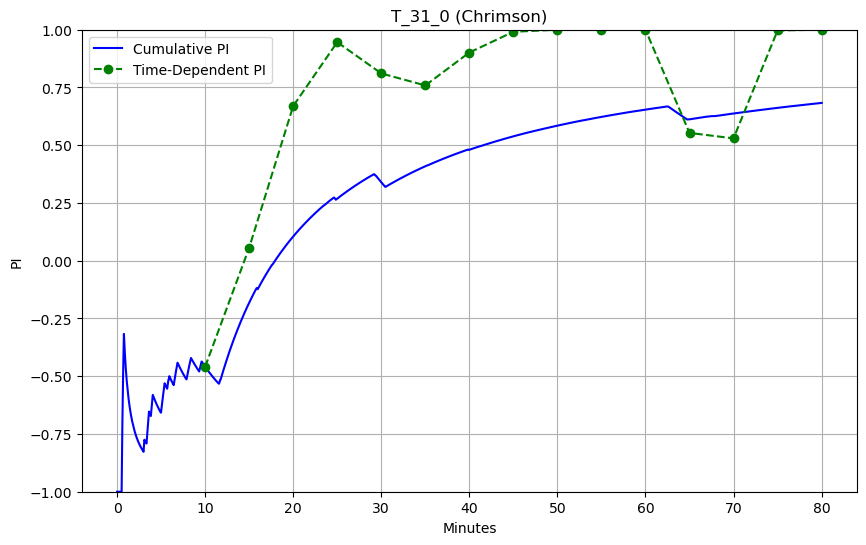

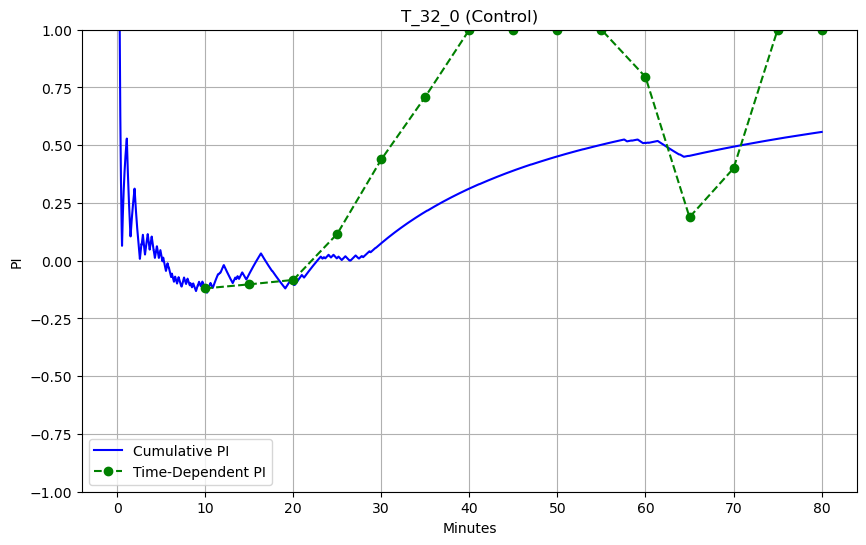

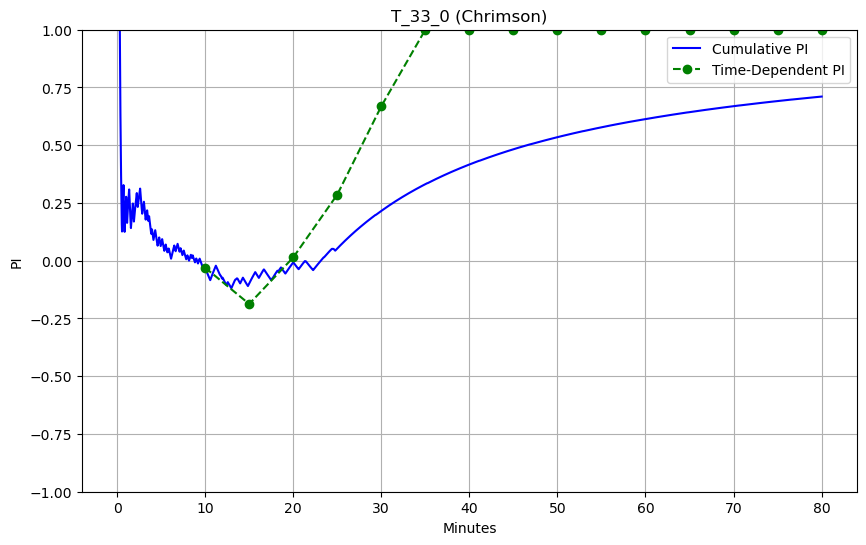

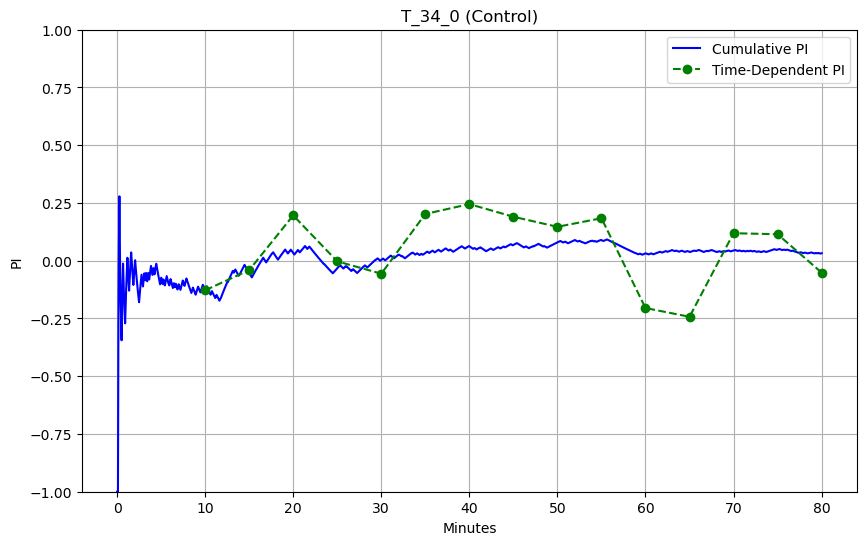

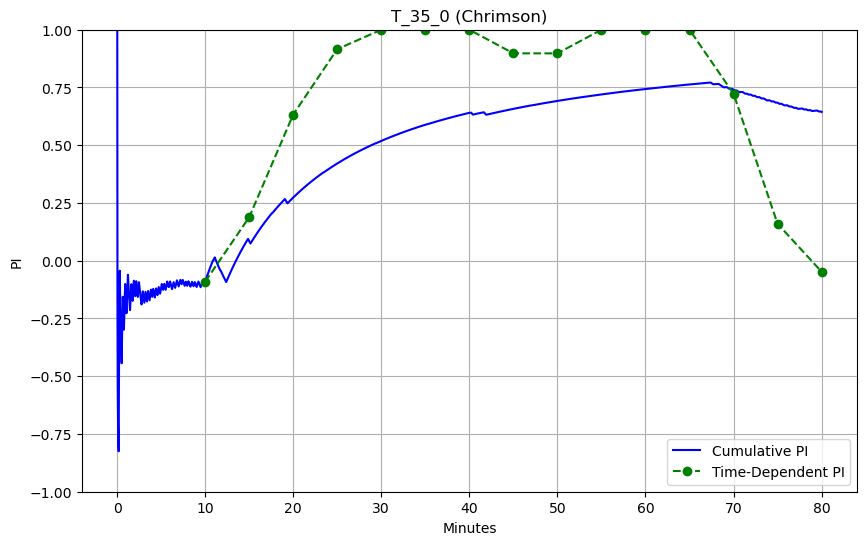

In [63]:
arena.plot_trackers_pis()

**Positional Plots:** Show the X positions of each tracker as a function of time.

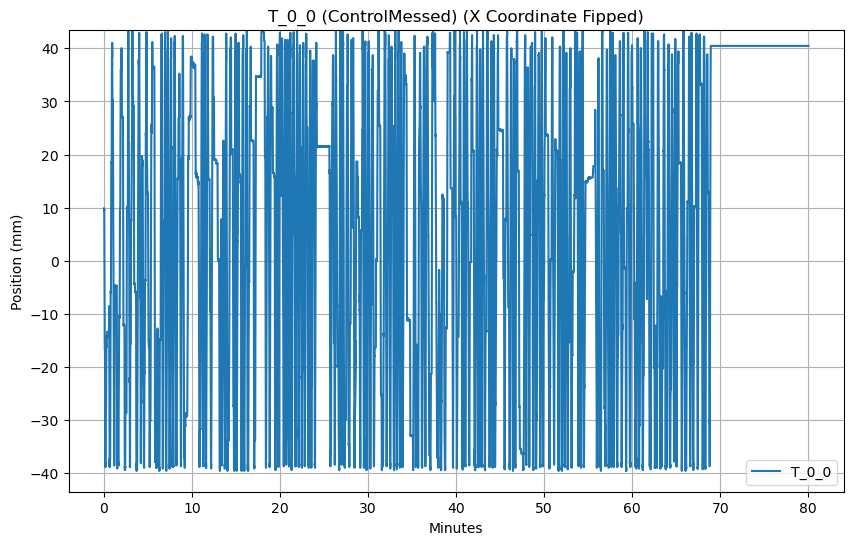

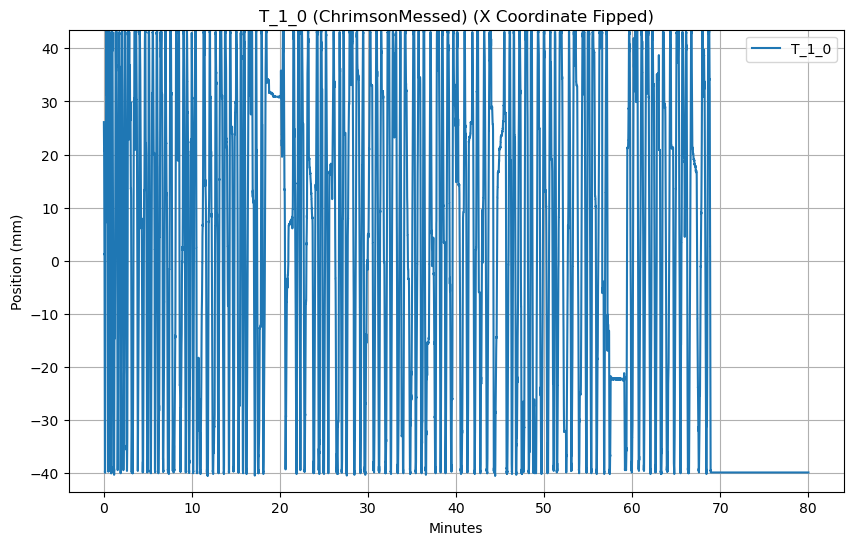

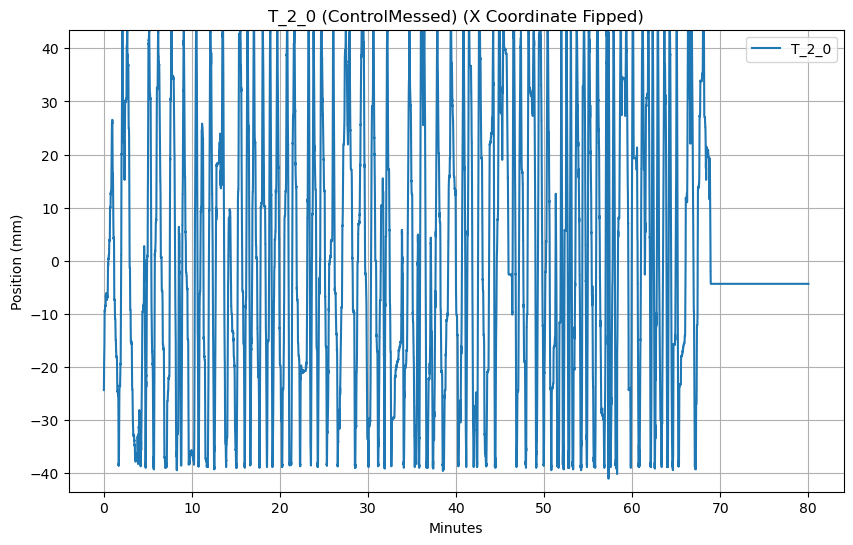

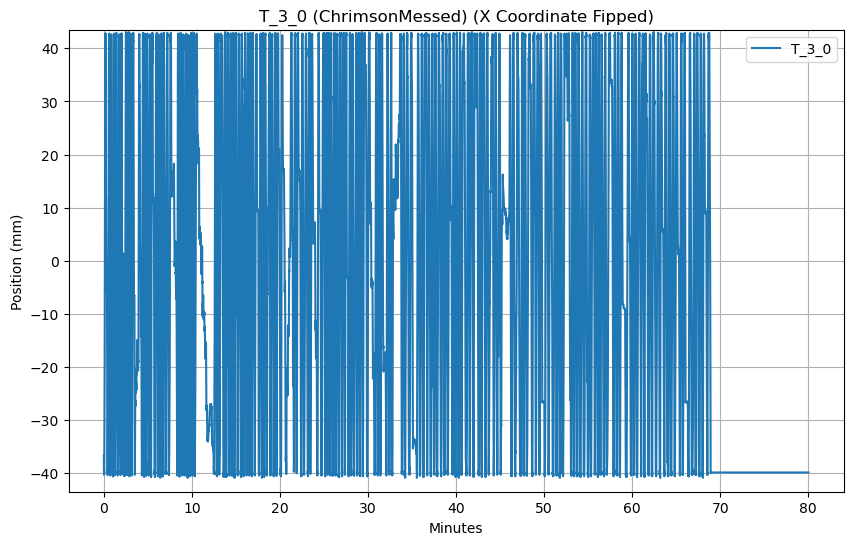

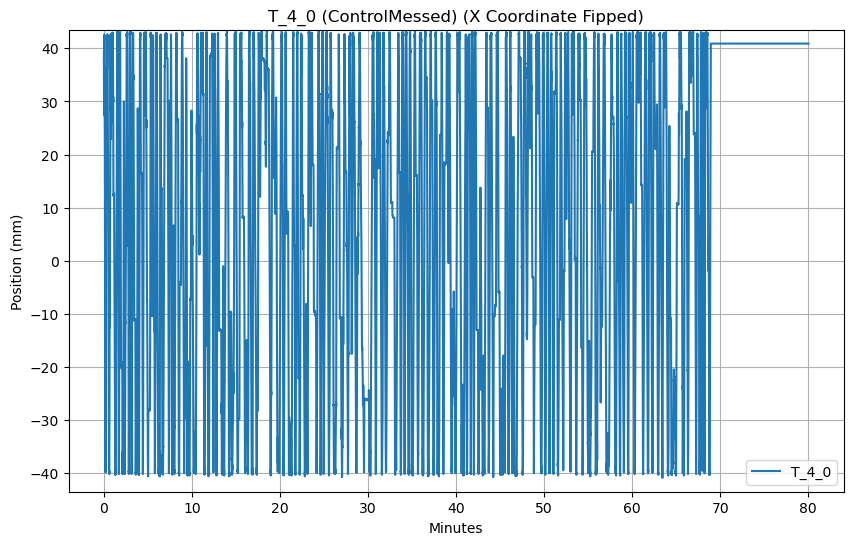

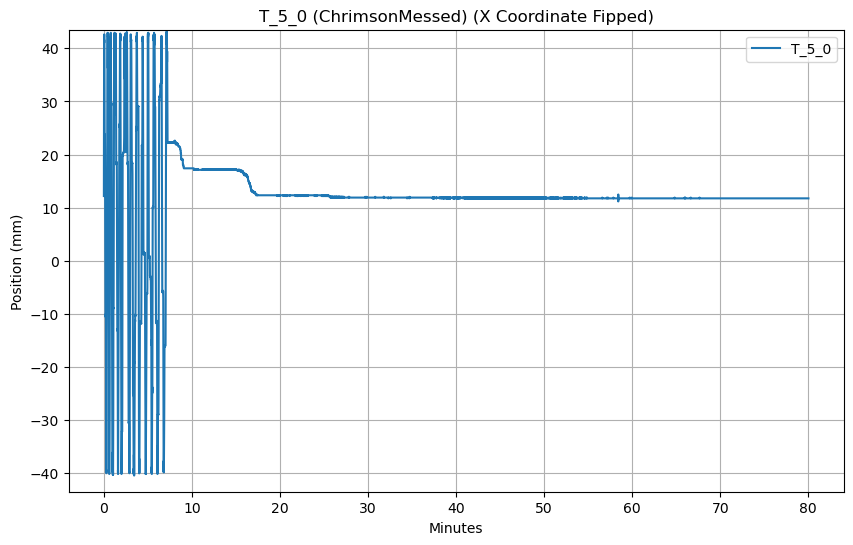

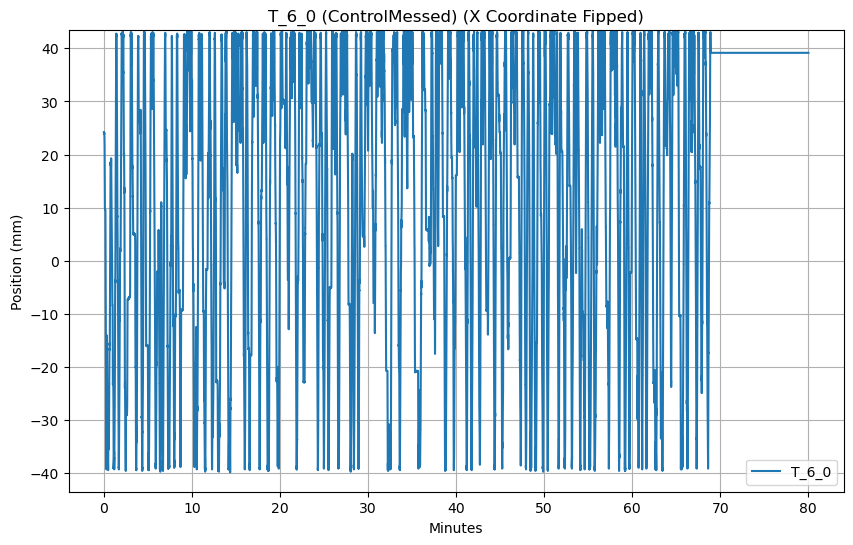

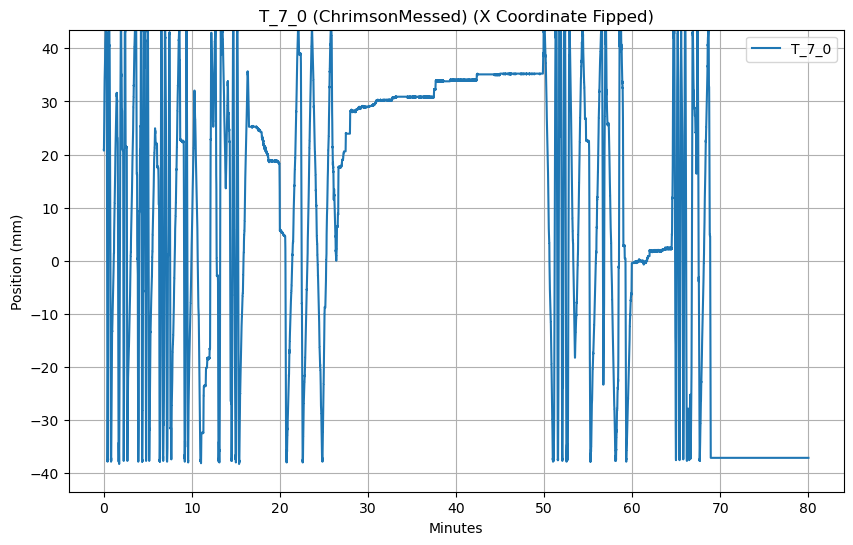

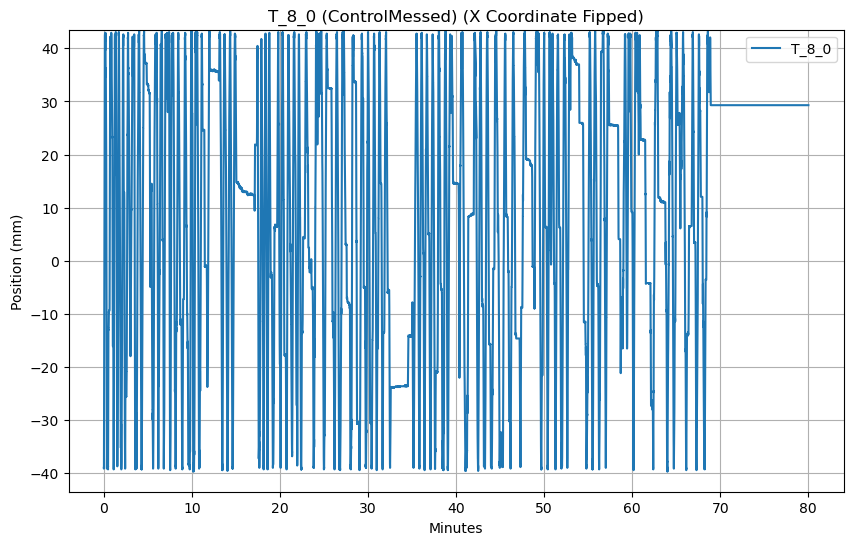

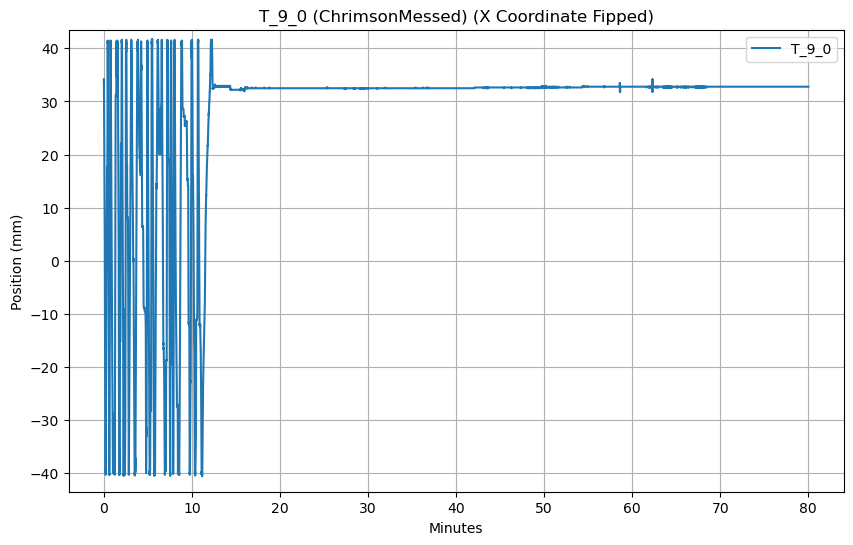

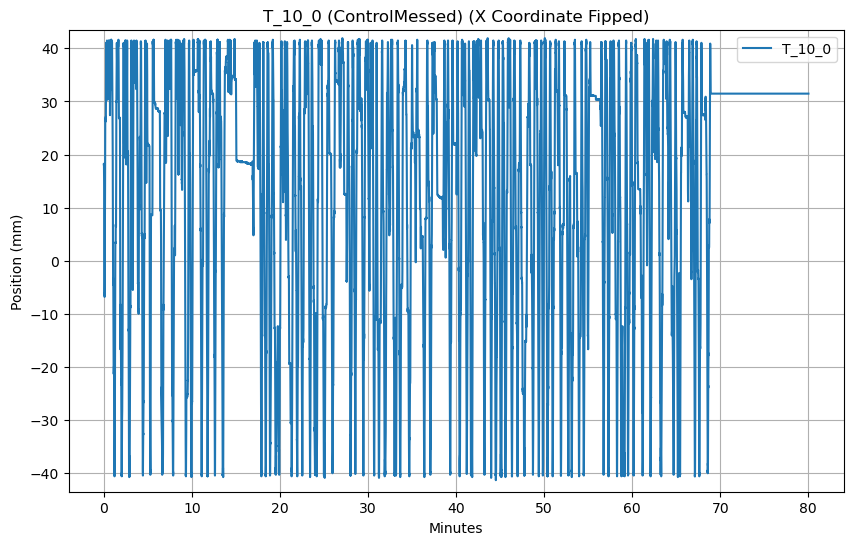

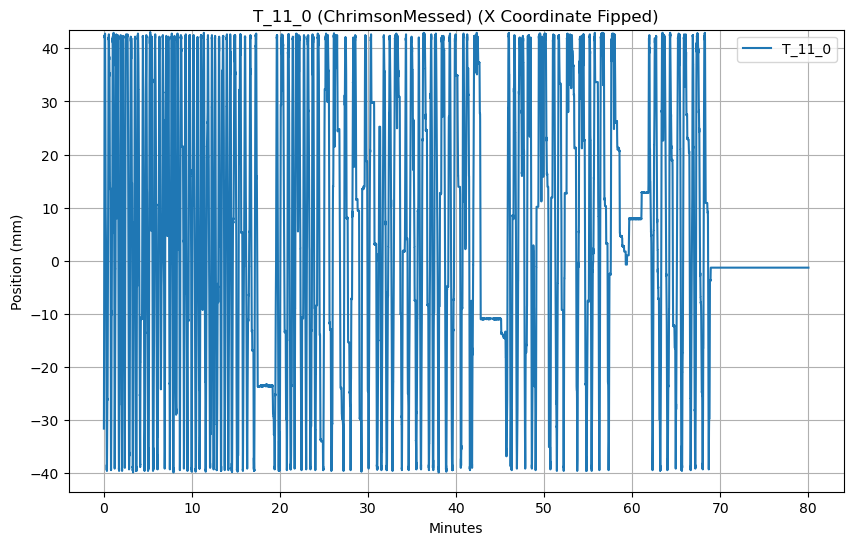

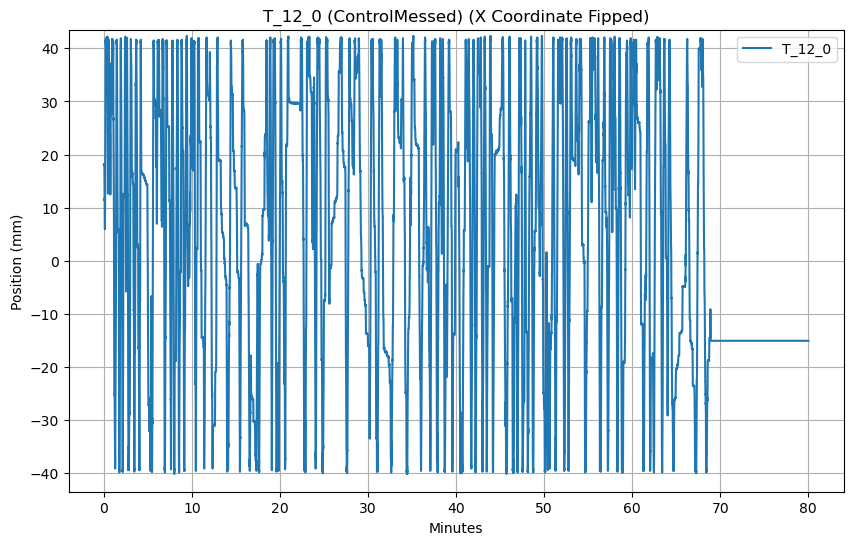

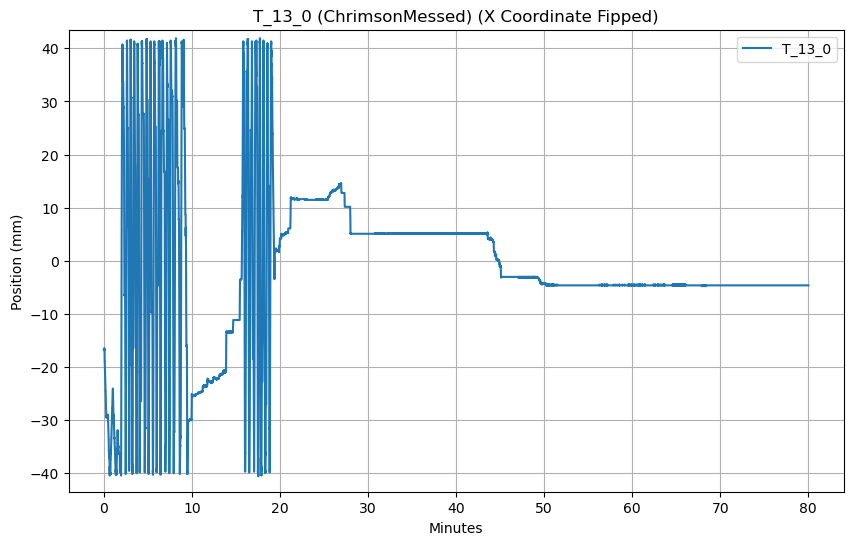

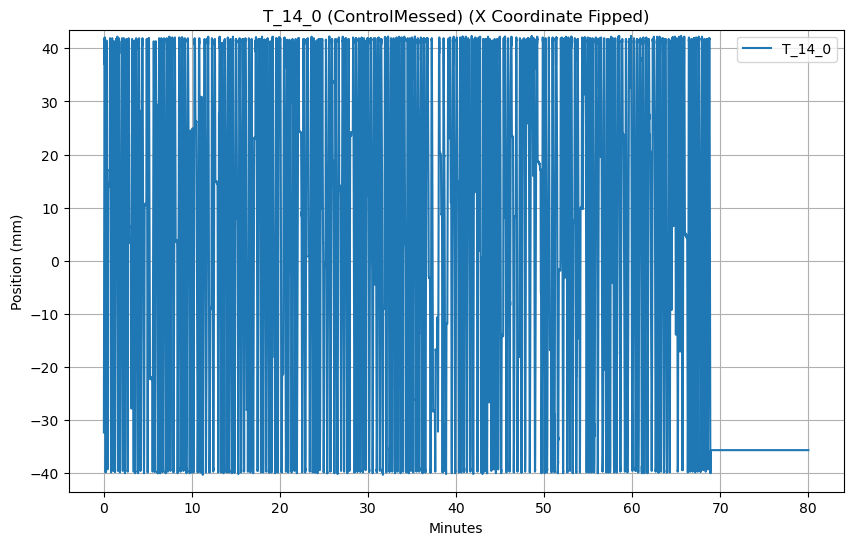

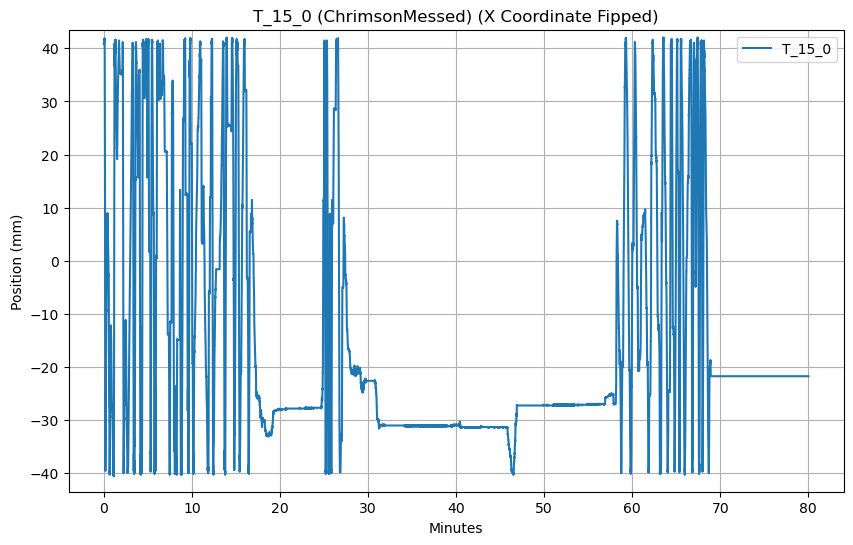

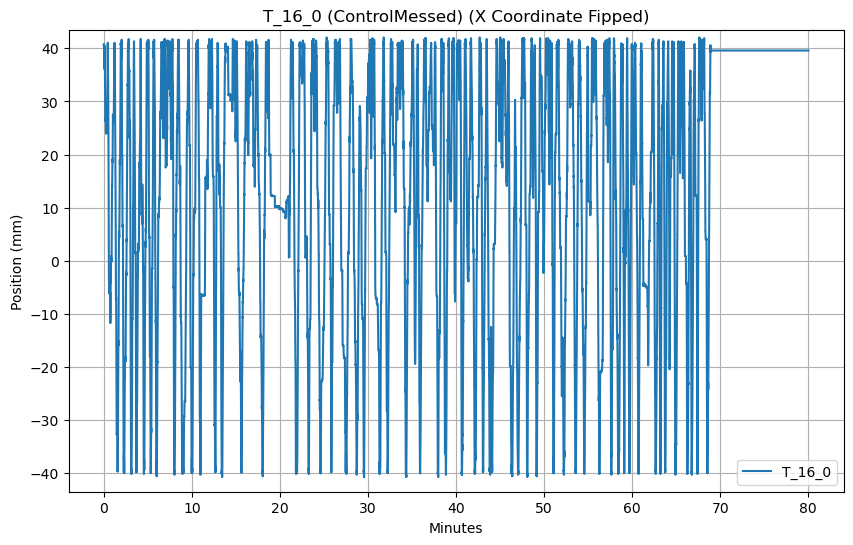

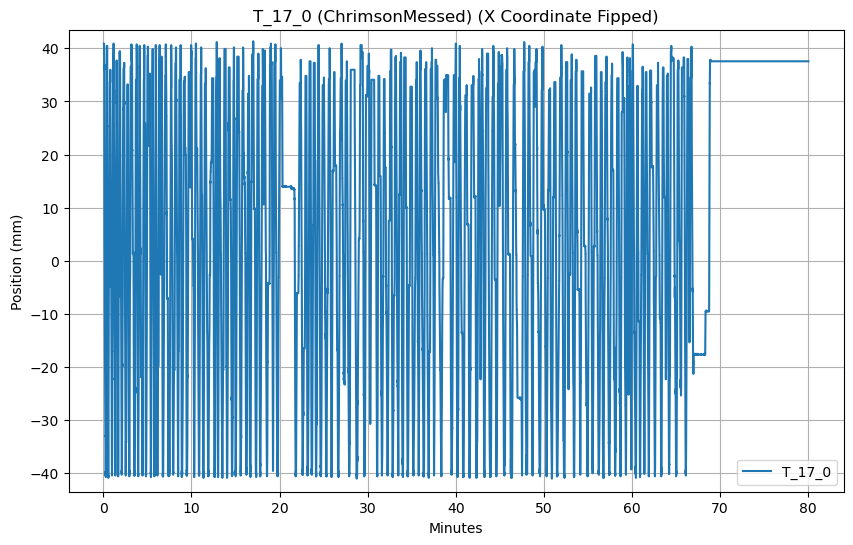

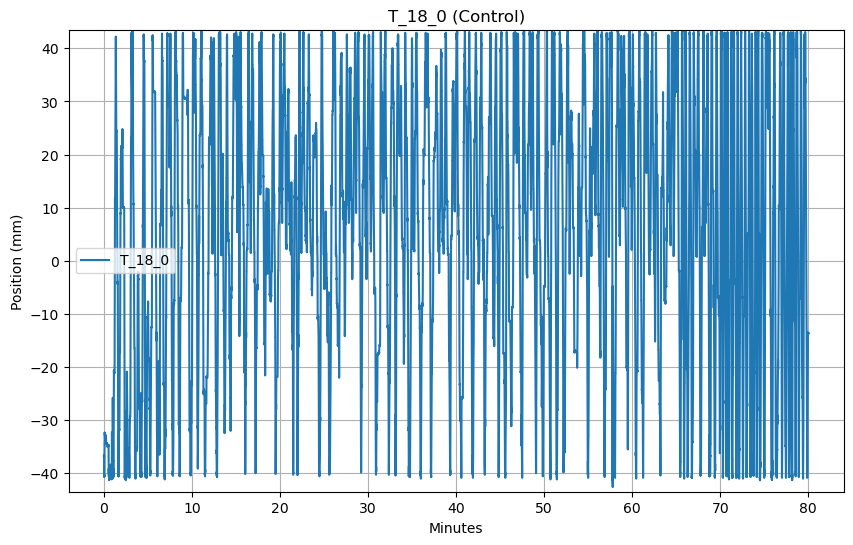

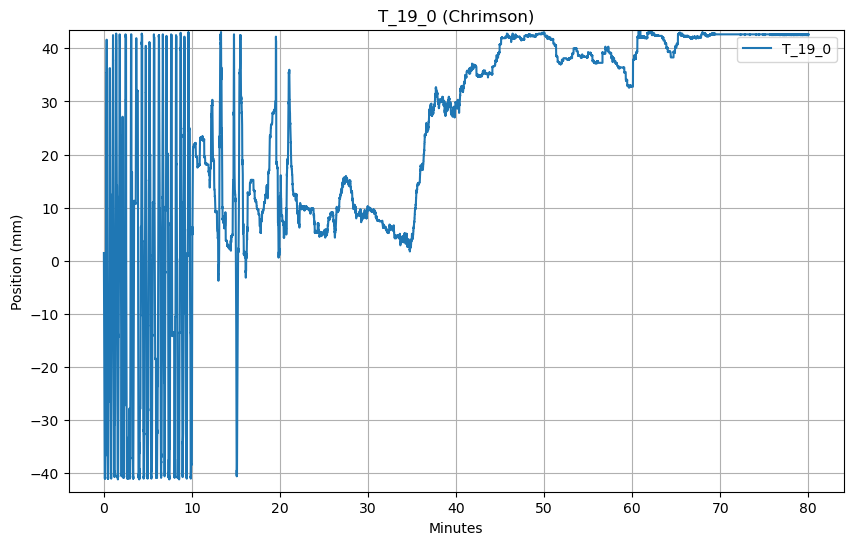

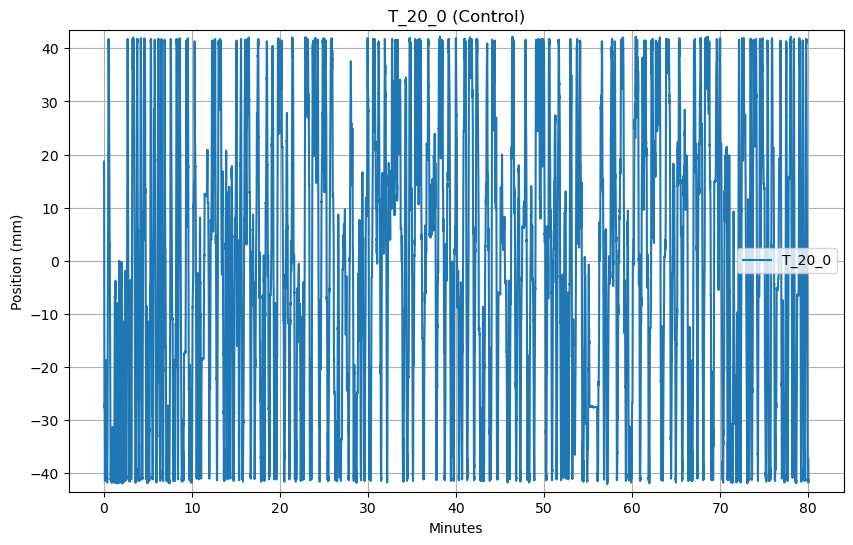

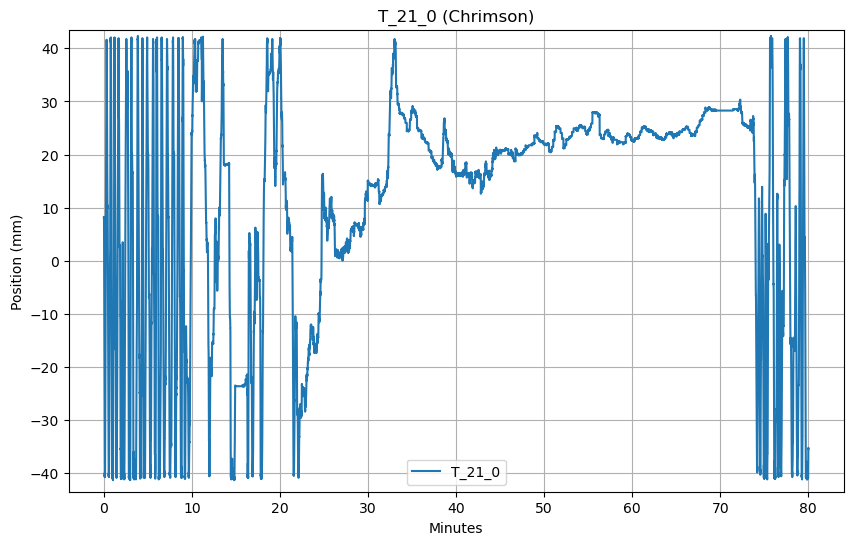

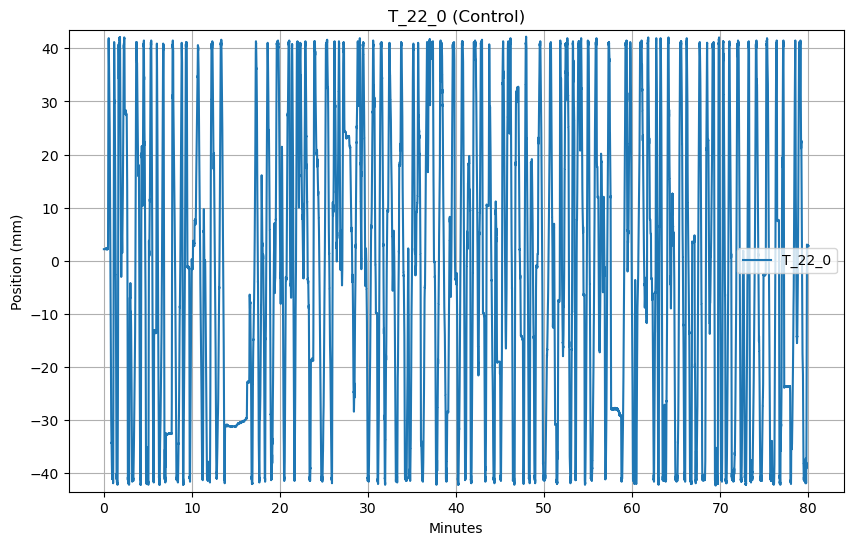

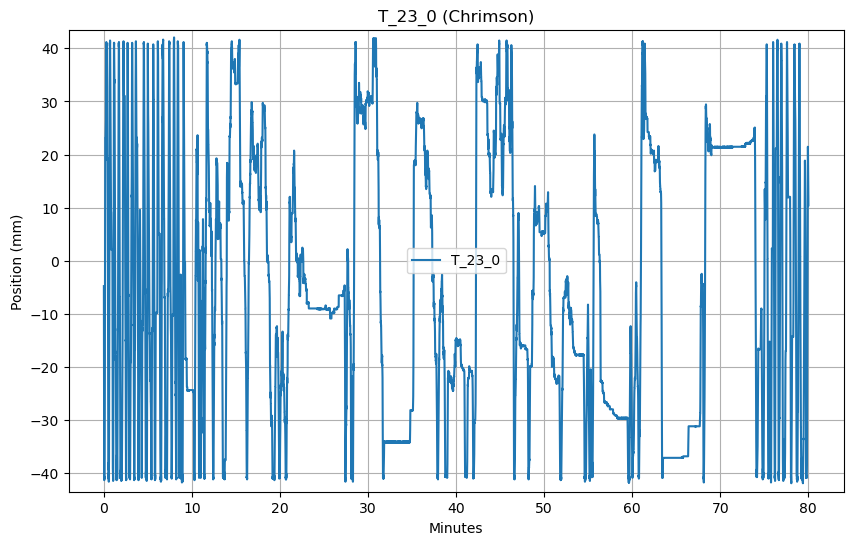

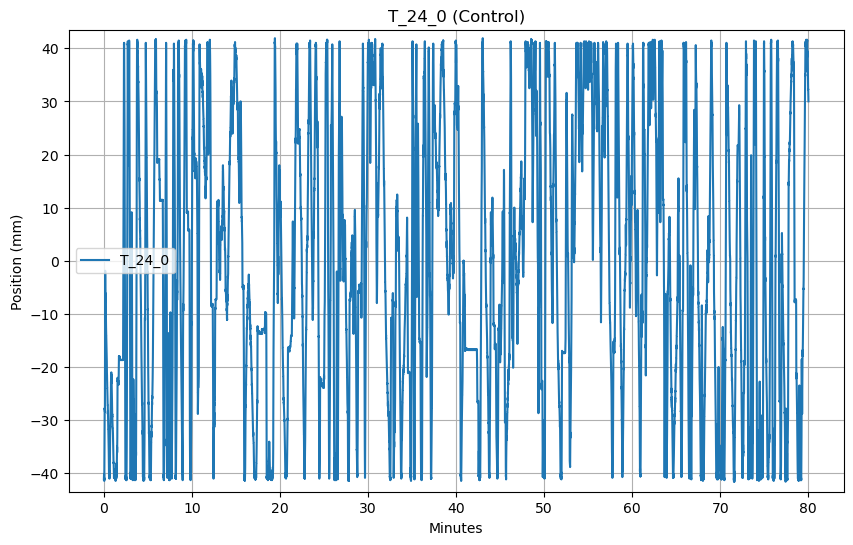

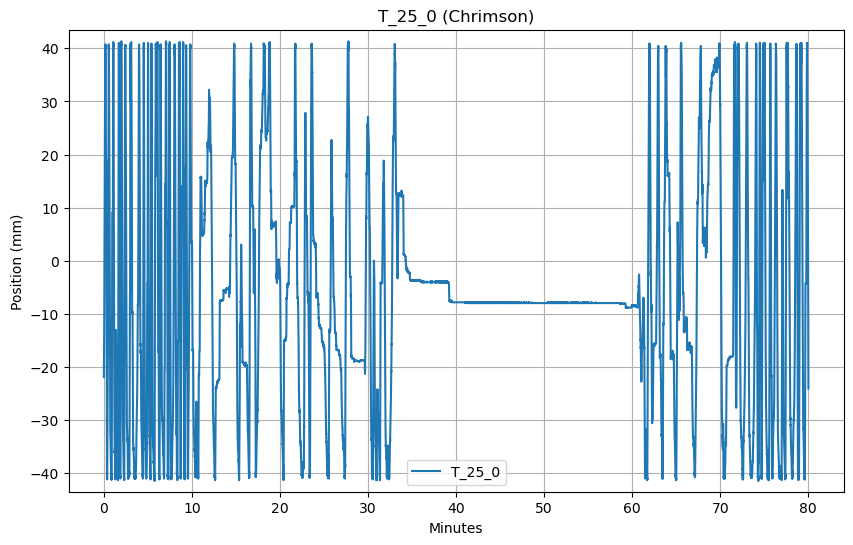

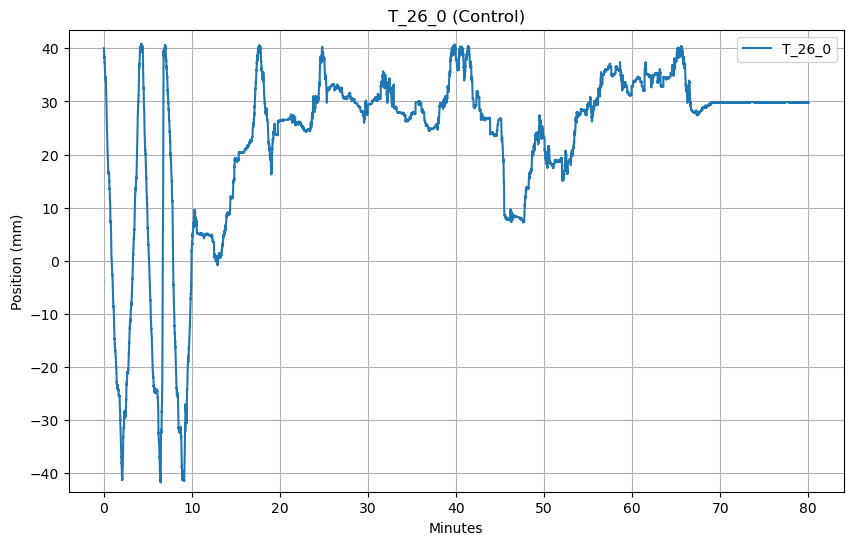

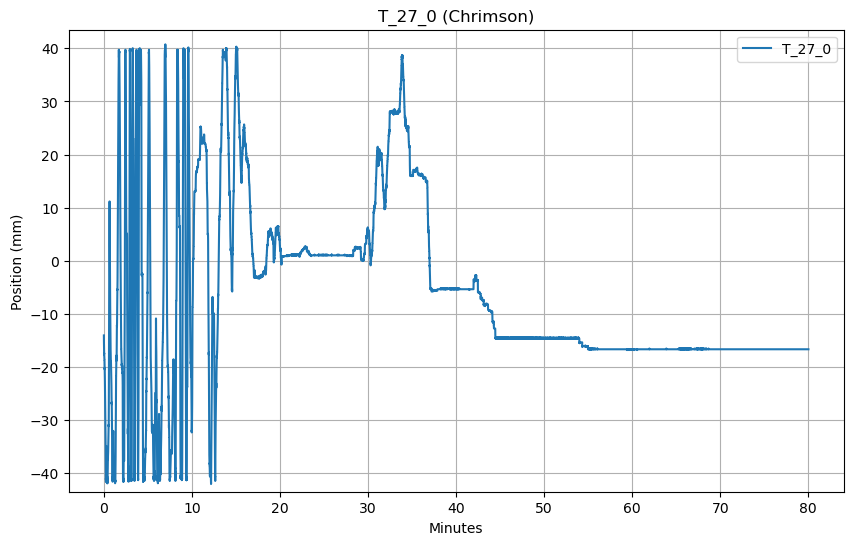

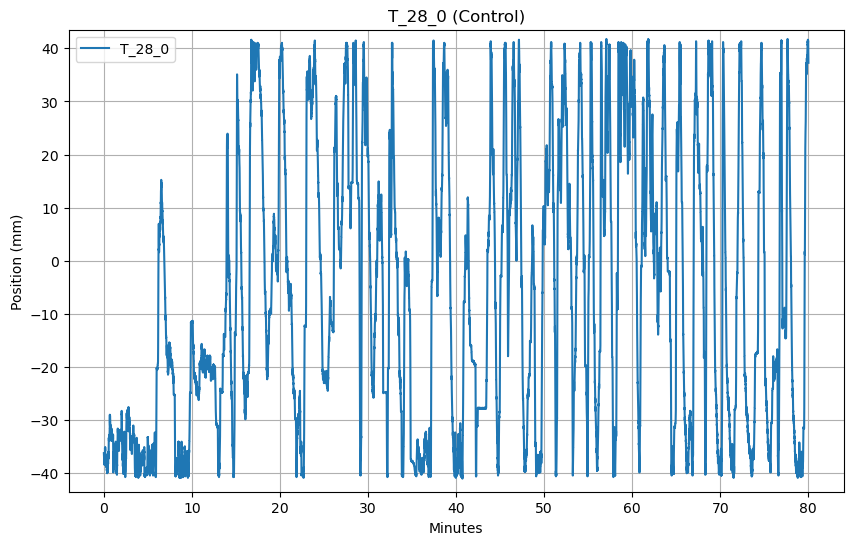

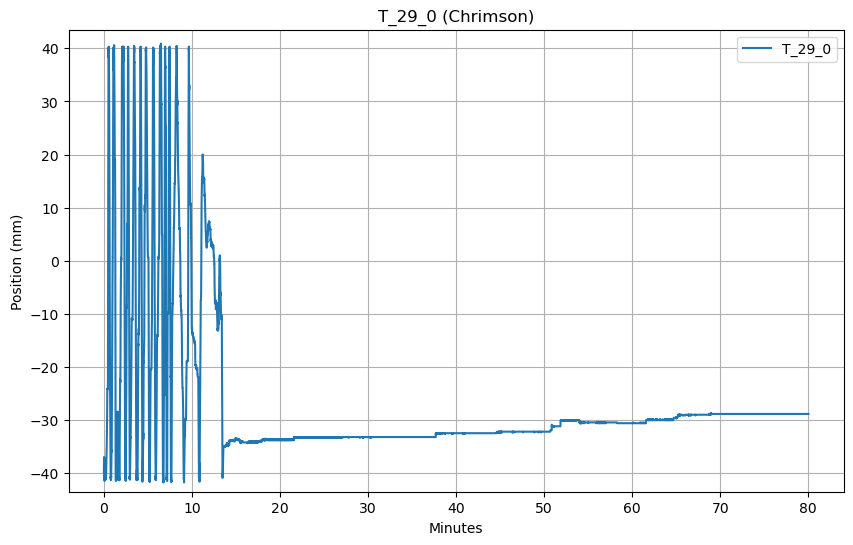

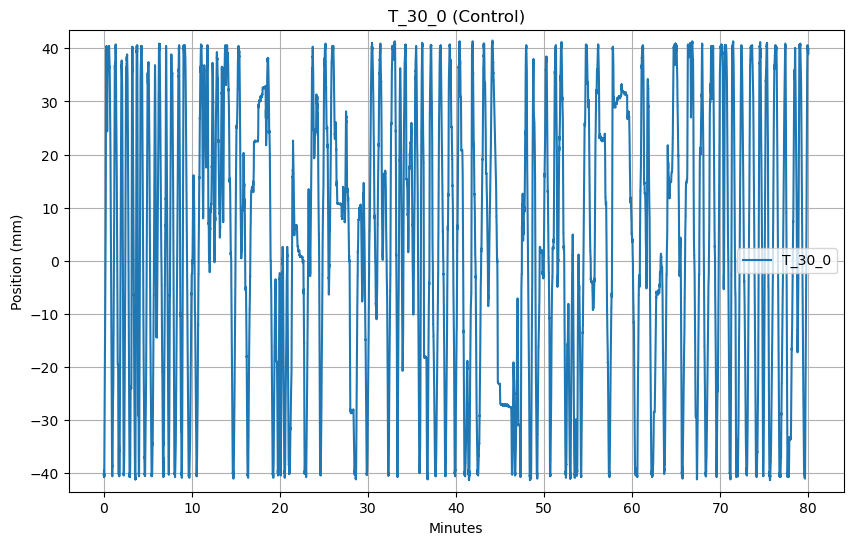

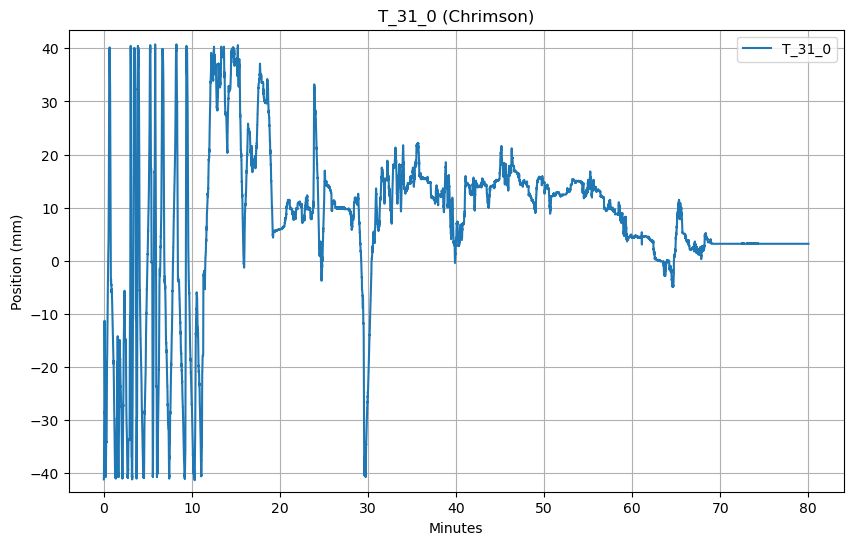

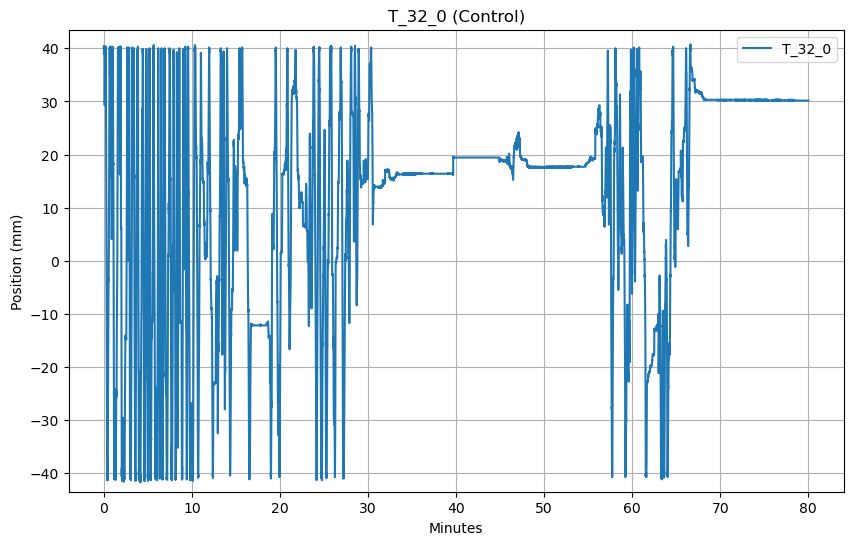

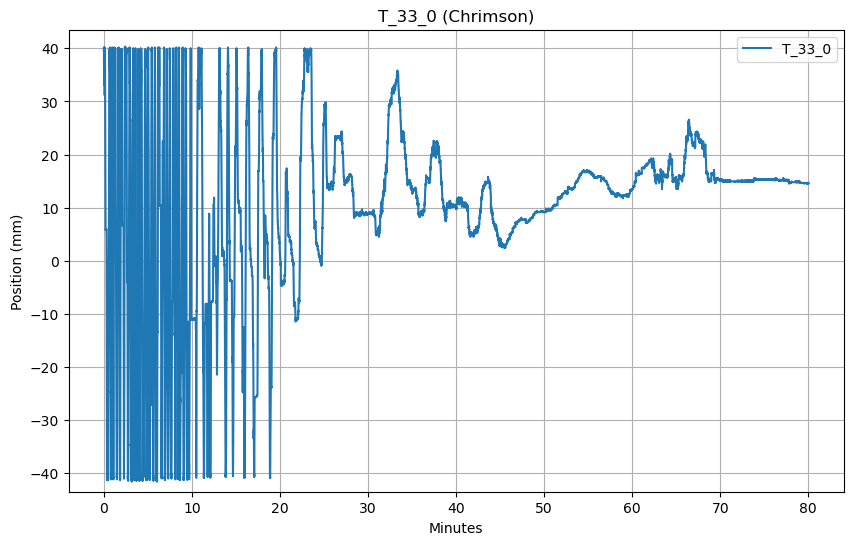

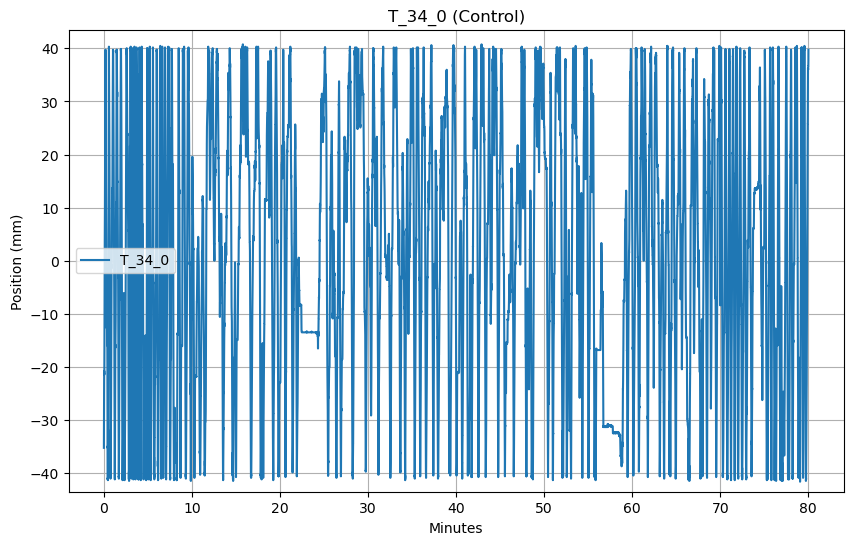

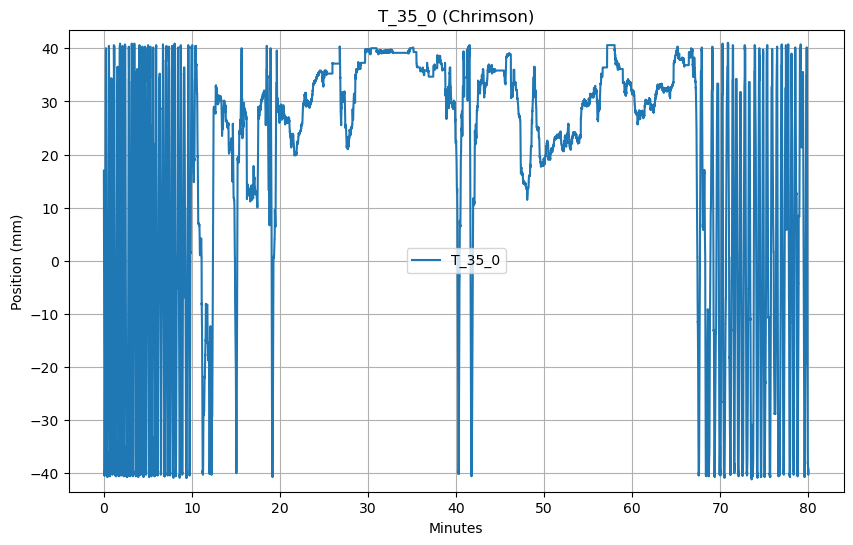

In [64]:
arena.plot_trackers_x()